In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from funzioni_tutte_nuove import *
from scipy.spatial.distance import pdist, squareform

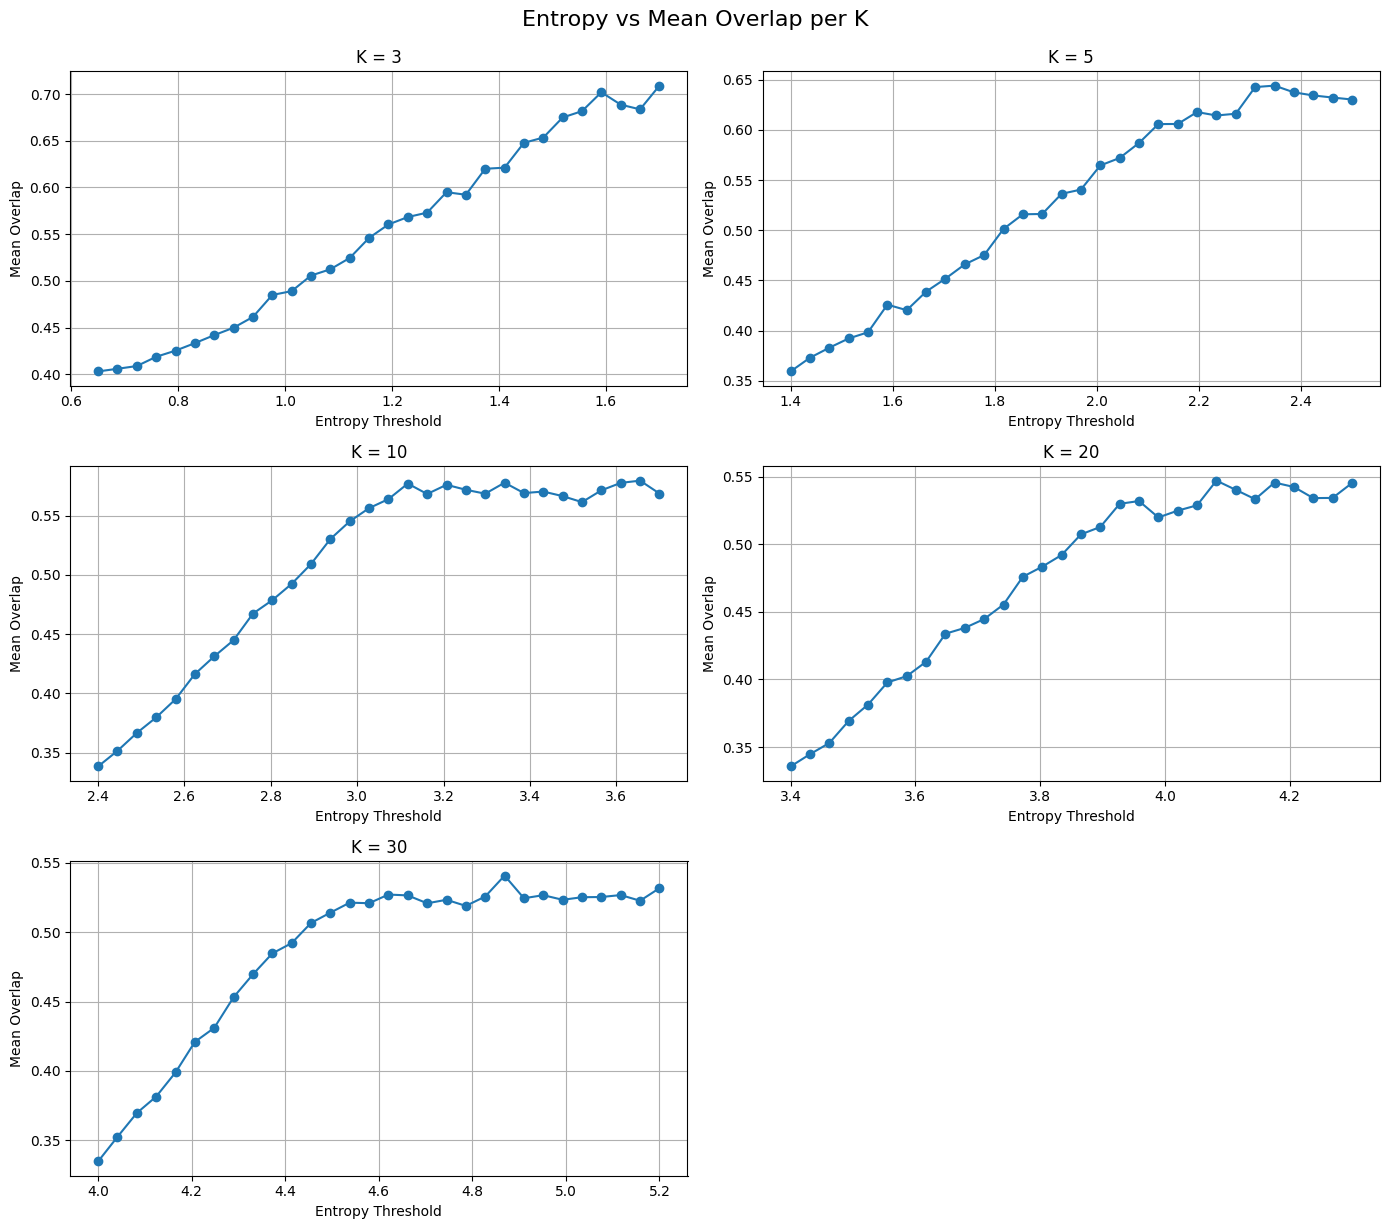

In [3]:
entropy_values = []
overlap_values = []
runs_dict = {}
num_run = 3
N = 100
n_points = 30  # Assicurati che sia definito

entropy_ranges = {
    3: np.linspace(0.65, 1.7, n_points),
    5: np.linspace(1.4, 2.5, n_points),
    10: np.linspace(2.4, 3.7, n_points),
    20: np.linspace(3.4, 4.3, n_points),
    30: np.linspace(4.0, 5.2, n_points),
}

fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

for idx, (K, entropies) in enumerate(entropy_ranges.items()): 
    runs_dict = {}
    for i in range(num_run):
        runs_dict[i] = {}
        entropy_values = []
        overlap_values = []
        runs_dict[i]['entropy'] =  []
        runs_dict[i]['overlap'] = []

        for entropy_threshold in entropies:
            pop = generate_population(K, N, entropy_threshold)
            entropy_values.append(entropy_threshold)
            overlap = calculate_total_overlap(pop)
            overlap_values.append(overlap)

        runs_dict[i]['entropy'] = entropy_values
        runs_dict[i]['overlap'] = overlap_values

    num_thresholds = len(runs_dict[0]['overlap'])
    mean_overlaps = []
    entropy_values = runs_dict[0]['entropy']

    for j in range(num_thresholds):
        overlaps_at_j = [runs_dict[i]['overlap'][j] for i in range(num_run)]
        mean_overlaps.append(np.mean(overlaps_at_j))

    axs[idx].plot(entropy_values, mean_overlaps, marker='o', linestyle='-')
    axs[idx].set_title(f'K = {K}')
    axs[idx].set_xlabel('Entropy Threshold')
    axs[idx].set_ylabel('Mean Overlap')
    axs[idx].grid(True)

# Se ci sono meno di 6 subplot, nascondi quelli vuoti
for i in range(len(entropy_ranges), len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.suptitle('Entropy vs Mean Overlap per K', fontsize=16, y=1.02)
plt.show()

# LET'S VERIFY PAPER VALUE FOR K=3 overlap-entropy

Popolazione nel simplesso con Initial Overlap = 0.39 S_trashold = 0.60
Popolazione nel simplesso con Initial Overlap = 0.56 S_trashold = 1.20
Popolazione nel simplesso con Initial Overlap = 0.66 S_trashold = 1.50
Popolazione nel simplesso con Initial Overlap = 0.70 S_trashold = 1.60


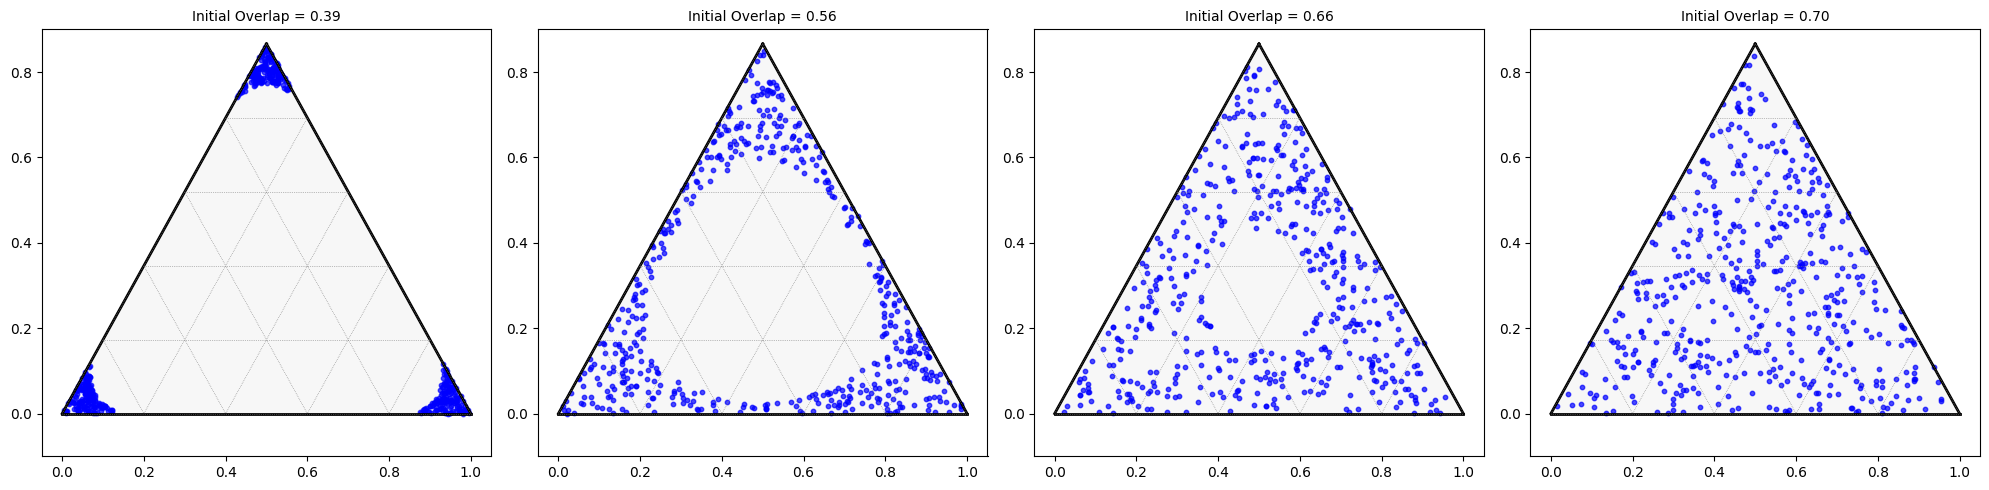

In [6]:
entropy_threshold_values = [0.6,1.2 ,1.5, 1.6]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
K = 3
N = 500
for i, entropy_threshold in enumerate(entropy_threshold_values):
    pop = generate_population(K , N, entropy_threshold)
    o = calculate_total_overlap(pop)
    print(f"Popolazione nel simplesso con Initial Overlap = {o:.2f} S_trashold = {entropy_threshold:.2f}")
    title = f'Initial Overlap = {o:.2f}'
    plot_simplesso_with_ax(pop, axes[i], title)

plt.tight_layout()
plt.savefig('GENERATE POPULATION')
plt.show()

# ORA  EVOLVIAMO LA POPOLAZIONE 

FINAL COHESION VALUE 0.7073992866983964


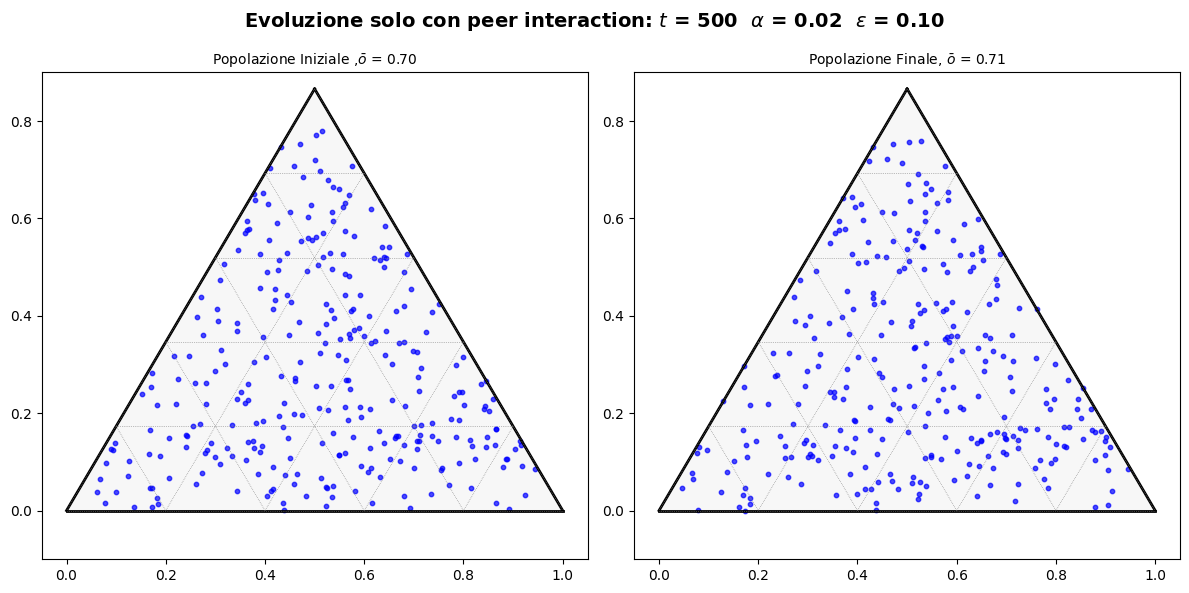

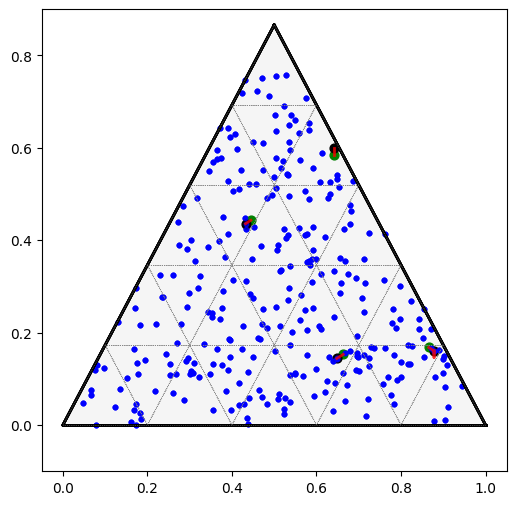

FINAL COHESION VALUE 0.7078017656480272


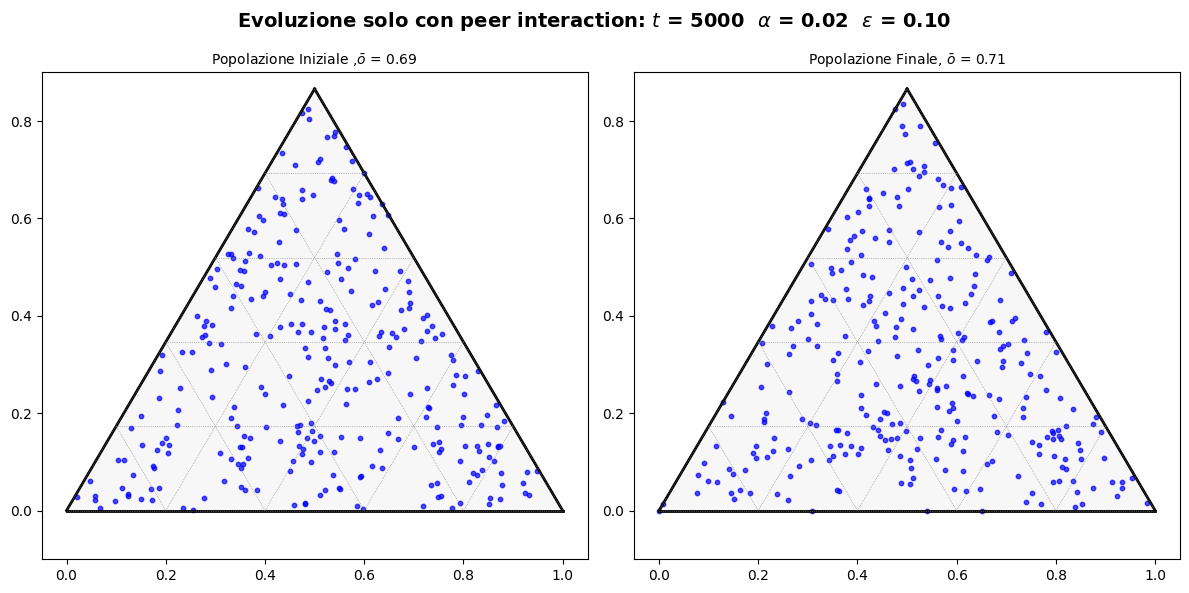

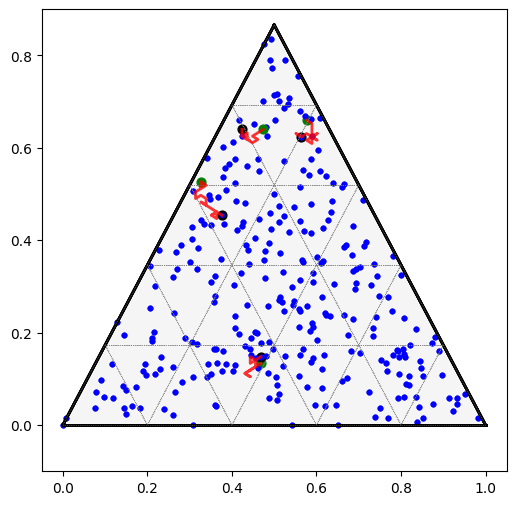

FINAL COHESION VALUE 0.9922400841543276


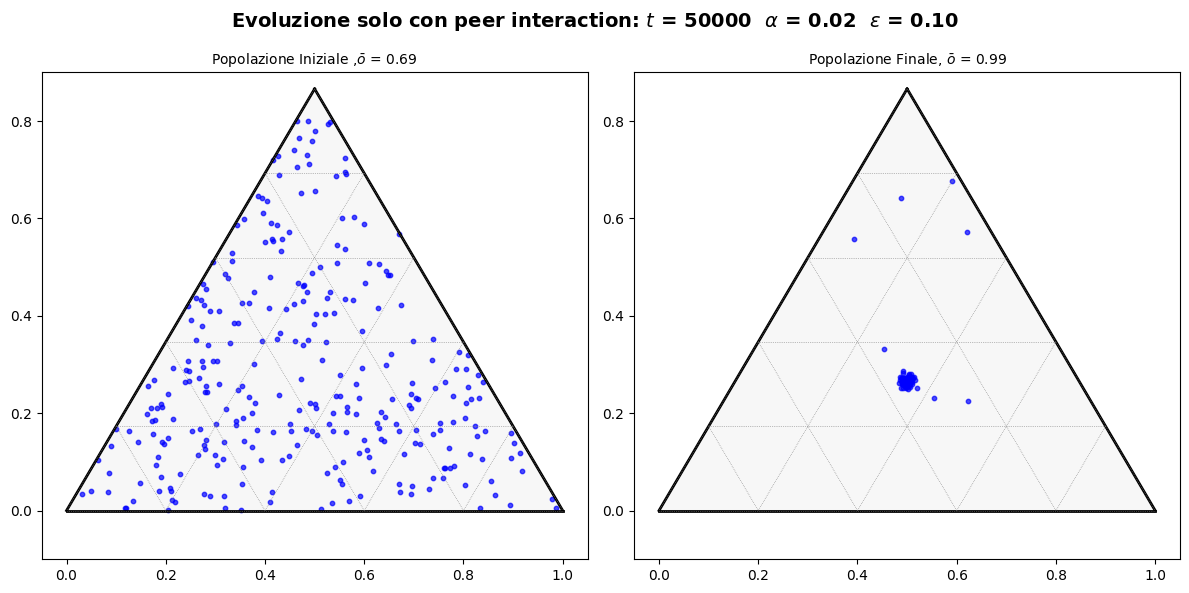

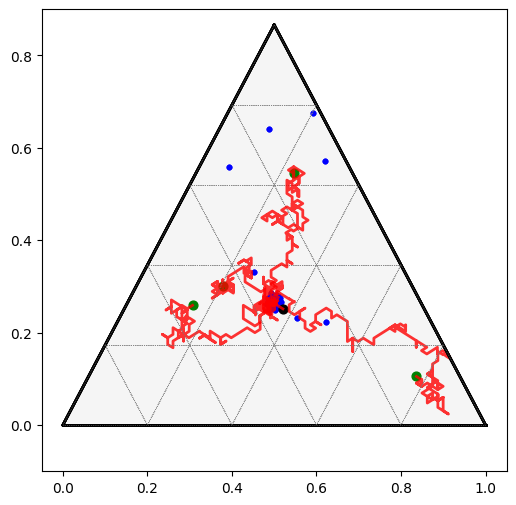

In [7]:
entropy_threshold =  1.6
alpha = 0.0167
N = 300
K=3
eps = 0.1
for time in [500, 5000, 50000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico , p , a = evolve_population_1( popolazione_iniziale , time , eps, alpha) 
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 6))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

# PARTE DI CLUSTERING

In [14]:
high_overlap = 1.6
low_overlap = 0.95

pop_high = generate_population(3 , 300, high_overlap)
pop_low =  generate_population(3 , 300, low_overlap) 

pop_finale_high, storico , p ,a  = evolve_population_1( pop_high , 100000 , 0.1, 0.0167 )
pop_finale_low , storico , a , p  =evolve_population_1( pop_low , 100000 , 0.1, 0.0167 )

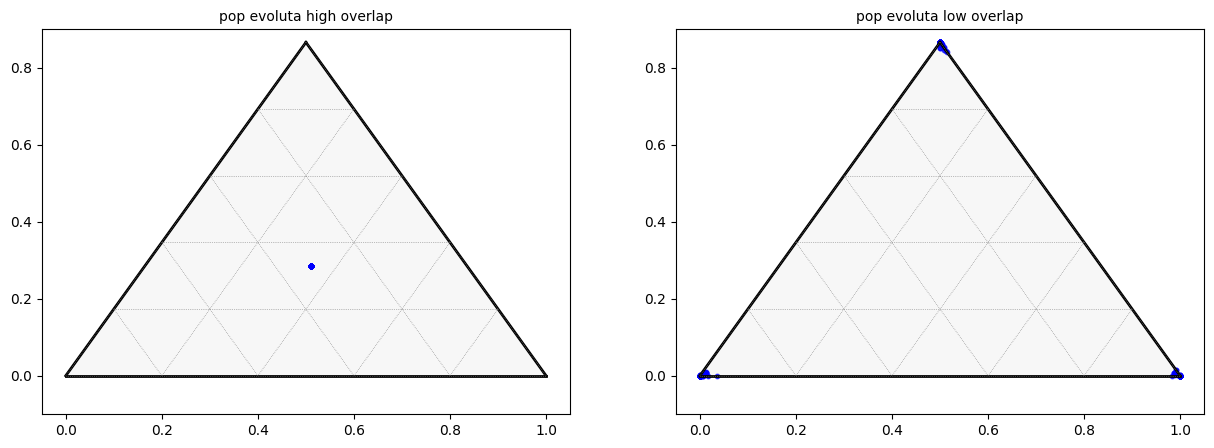

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_simplesso_with_ax(pop_finale_high,axes[0], 'pop evoluta high overlap')
plot_simplesso_with_ax(pop_finale_low ,axes[1], 'pop evoluta low overlap')

In [16]:
labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.8)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ 3 (o comunque un valore più alto)

PR high: 1.0
PR low: 2.9706891998943754


In [17]:
#attenzione sta cella sul pc mio ci mette 20 min

popolazioni = {}
Ks = [3,5,10]
eps = 0.1
alphas = [0.0167, 0.01 , 0.005 , 0.0025 , 0.00167]
times = [ 100000,300000,1000000,5000000,500000 ]
n_points = 50
entropy_ranges = {
    3: np.linspace(0.8, 1.6, n_points),
    5: np.linspace(1.6, 2.4, n_points),
    10: np.linspace(2.5, 3.7, n_points),
    20: np.linspace(3.6, 4.3, n_points),
    30: np.linspace(4.2, 5.5, n_points),
}

for i in range(3):
    print('K', Ks[i])
    alpha = alphas[i]
    K = Ks[i]
    time = times[i]
    popolazioni[K] = {}
    

    for entropy_threshold in entropy_ranges[K]:
        pop = generate_population(K, 70, entropy_threshold)
        o = calculate_total_overlap(pop)
        pop_evoluta  = evolve_population_2(pop, time, eps, alpha)
        cluster_labels = hierarchical_clustering_K(pop_evoluta, 0.8)
        pr_value = compute_PR(cluster_labels)
        popolazioni[K][o] = pr_value

# Check for any agents that drifted off the simplex
sums = np.sum(pop_evoluta, axis=1)
invalid_indices = np.where(~np.isclose(sums, 1.0))[0]

if len(invalid_indices) > 0:
    print(f"Error: {len(invalid_indices)} agents do not sum to 1!")
    print(f"Sample sum: {sums[invalid_indices[0]]}")

K 3
K 5
K 10


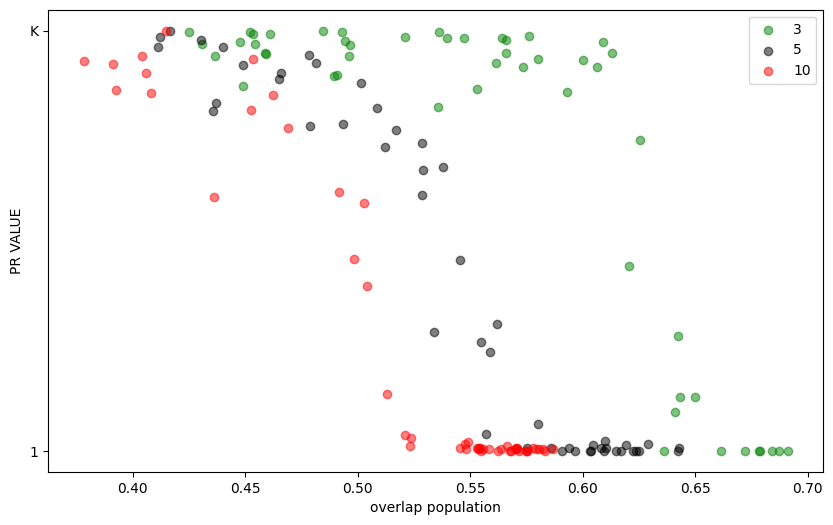

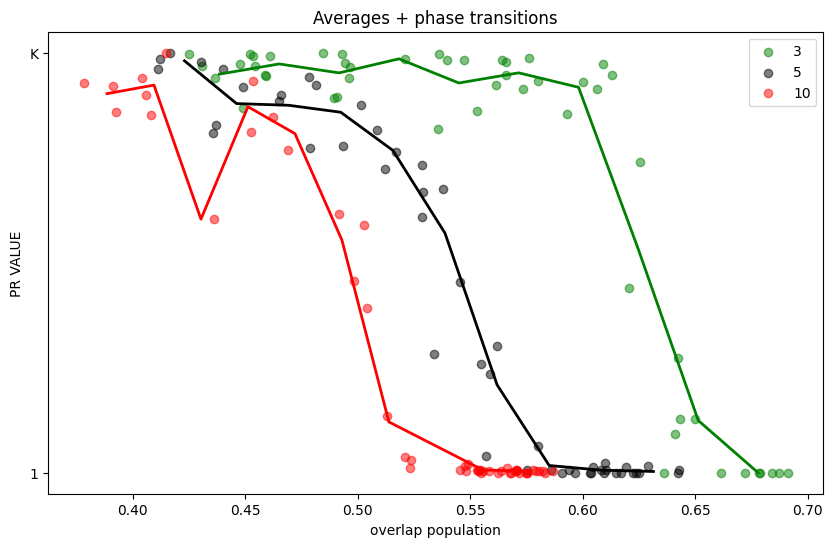

In [20]:
colors = ['green' , 'black' , 'red']
plt.figure(figsize=(10, 6))
for i,K in enumerate(Ks):
    
    x_values = list(popolazioni[K].keys()) 
    y_values = np.array(list(popolazioni[K].values())) 
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)
    plt.scatter(x_values,  data_normalized ,alpha = 0.5 , color = colors[i] , label = f'{K}')
    plt.yticks([1, 5], labels=["1", "K"])

plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO')



colors = ['green', 'black', 'red']
bin_count = 10
bin_averages = {}
plt.figure(figsize=(10, 6))

for i, K in enumerate(Ks):
    x_values = np.array(list(popolazioni[K].keys()))
    y_values = np.array(list(popolazioni[K].values()))

   
    x_min = y_values.min()
    x_max = y_values.max()
    data_normalized = 1 + (y_values - x_min) * (5 - 1) / (x_max - x_min)

    
    plt.scatter(x_values, data_normalized, alpha=0.5, color=colors[i], label=f'{K}')

    
    bins = np.linspace(x_values.min(), x_values.max(), bin_count + 1)
    bin_indices = np.digitize(x_values, bins)

    bin_means = []
    bin_centers = []

    for j in range(1, bin_count + 1):
        bin_mask = bin_indices == j
        if np.any(bin_mask):
            mean_value = data_normalized[bin_mask].mean()
            bin_means.append(mean_value)
            bin_centers.append((bins[j - 1] + bins[j]) / 2)

    bin_averages[K] = (np.array(bin_centers), np.array(bin_means))

for i, K in enumerate(Ks):
    x_avg, y_avg = bin_averages[K]
    plt.plot(x_avg, y_avg, color=colors[i], linewidth=2)

plt.yticks([1, 5], labels=["1", "K"])
plt.xlabel('overlap population')
plt.ylabel('PR VALUE')
plt.legend()
plt.title('Averages + phase transitions')
plt.savefig('PHASE_TRANSITION_SIRBU_LORETO_averages')

# INTRODUCO EXTERNAL INFO INTERACTION

<function matplotlib.pyplot.show(close=None, block=None)>

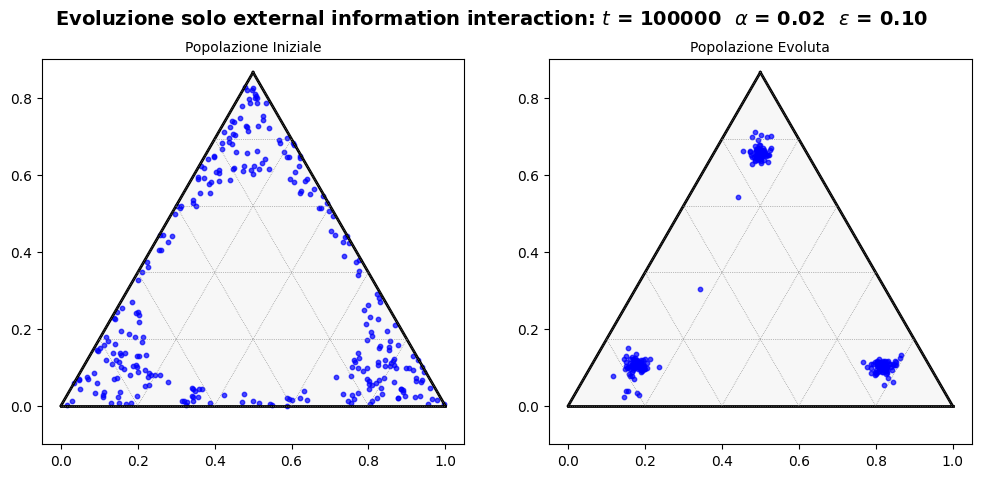

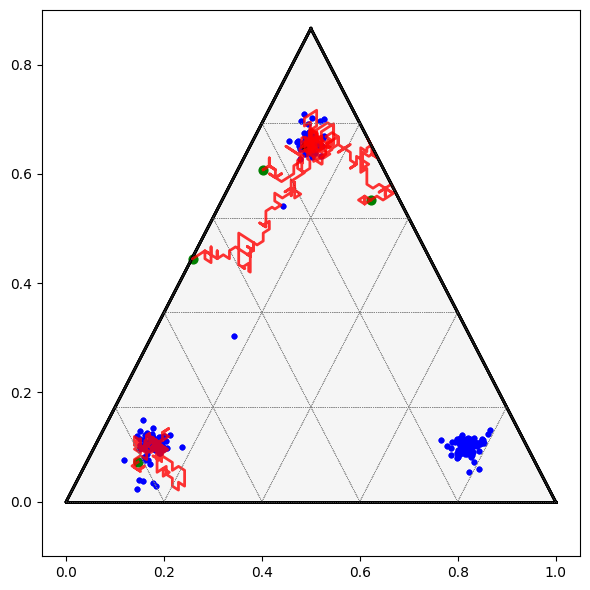

In [6]:
PI = 0.5
a = 0.75
K  = 3
I = external_info(3,a)
time = 100000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_prop_info ,storico = evolve_population_with_info_proportional(np.array(pop) , time , 0.1, 0.0167 , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione solo external information interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f}", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_prop_info, axes[1], "Popolazione Evoluta")
fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)
plt.tight_layout()
plt.show

# EXTERNAL INFO AND PEER

/Users/camilla/Desktop/Scrivania - MacBook Air di Camilla/DOTTORATO/alice/Cooperation-main/venv/lib/python3.14/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


<function matplotlib.pyplot.show(close=None, block=None)>

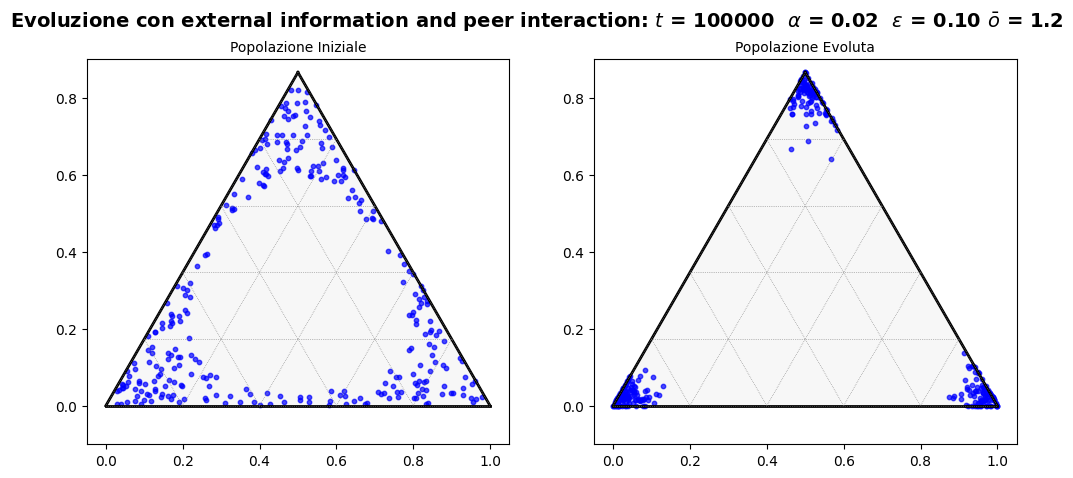

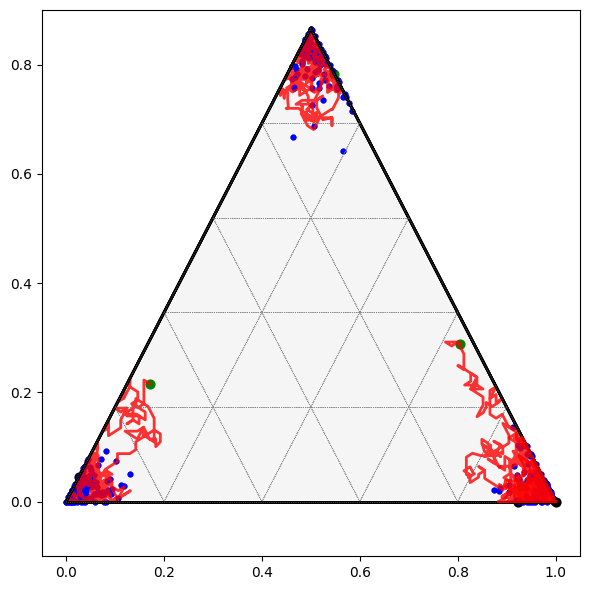

In [3]:
PI = 0.5
a = 0.75
eps = 0.1
alpha = 0.0167
I = external_info(3,a)
time = 100000
entropy_threshold = 1.2
K=3
pop = generate_population(K ,300, entropy_threshold)
pop_evoluta_with_info_and_peer ,storico = evolve_population_with_prop_info_and_peer( np.array(pop) , time ,eps,alpha , I , PI)    
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione con external information and peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} $\bar{{o}}$ = 1.2", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_evoluta_with_info_and_peer, axes[1], "Popolazione Evoluta")

fig, ax = plt.subplots(figsize=(6, 6))
index_user = 23 # Cambia questo per tracciare un altro individuo
plot_user_trajectory_from_dict(storico, index_user, ax)
plot_user_trajectory_from_dict(storico,131, ax)
plot_user_trajectory_from_dict(storico, 71, ax)
plot_user_trajectory_from_dict(storico, 3, ax)

plt.tight_layout()
plt.show

##  OPEN MINDED INTERACTION

FINAL COHESION VALUE 0.9795645687617225


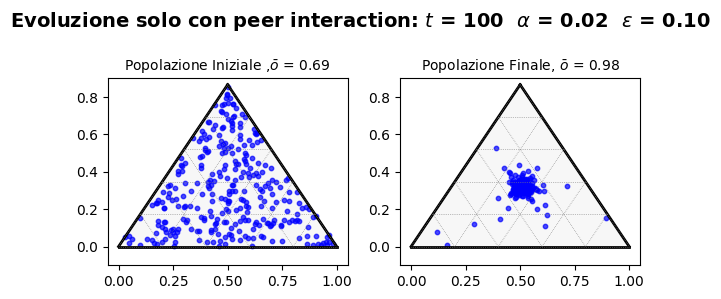

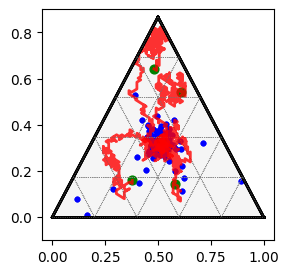

FINAL COHESION VALUE 0.9459380376679318


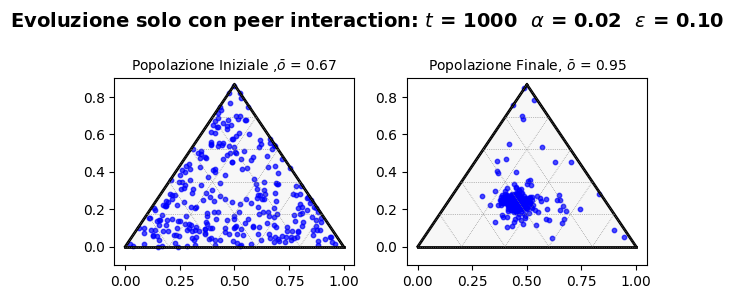

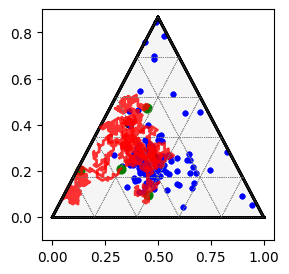

FINAL COHESION VALUE 0.9878335440828845


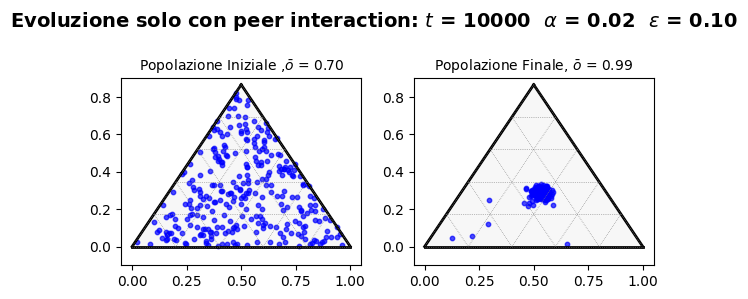

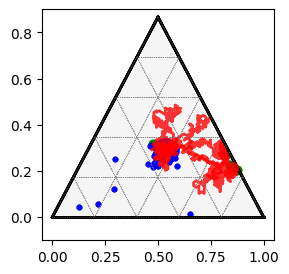

FINAL COHESION VALUE 0.990986546175802


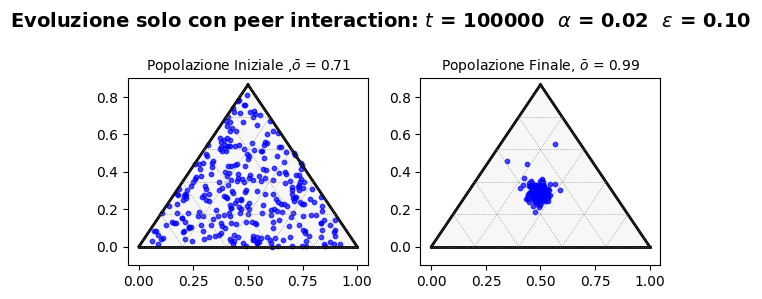

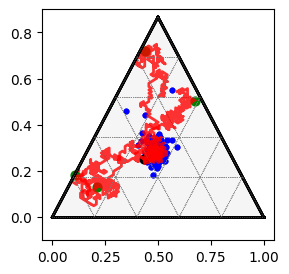

In [4]:
entropy_threshold =  1.6
t = 100000
alpha = 0.0167
N = 300
K=3
eps = 0.1
p_om = 0.5

eps = 0.1
for time in [100, 1000, 10000, 100000]:
    fig, axes = plt.subplots(1, 2, figsize=(6, 3)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico, storico_interaction=evolve_population_p_om_fissata( popolazione_iniziale , t , eps, alpha ,p_om)

    
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(3, 3))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

/Users/camilla/Desktop/Scrivania - MacBook Air di Camilla/DOTTORATO/alice/Cooperation-main/venv/lib/python3.14/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


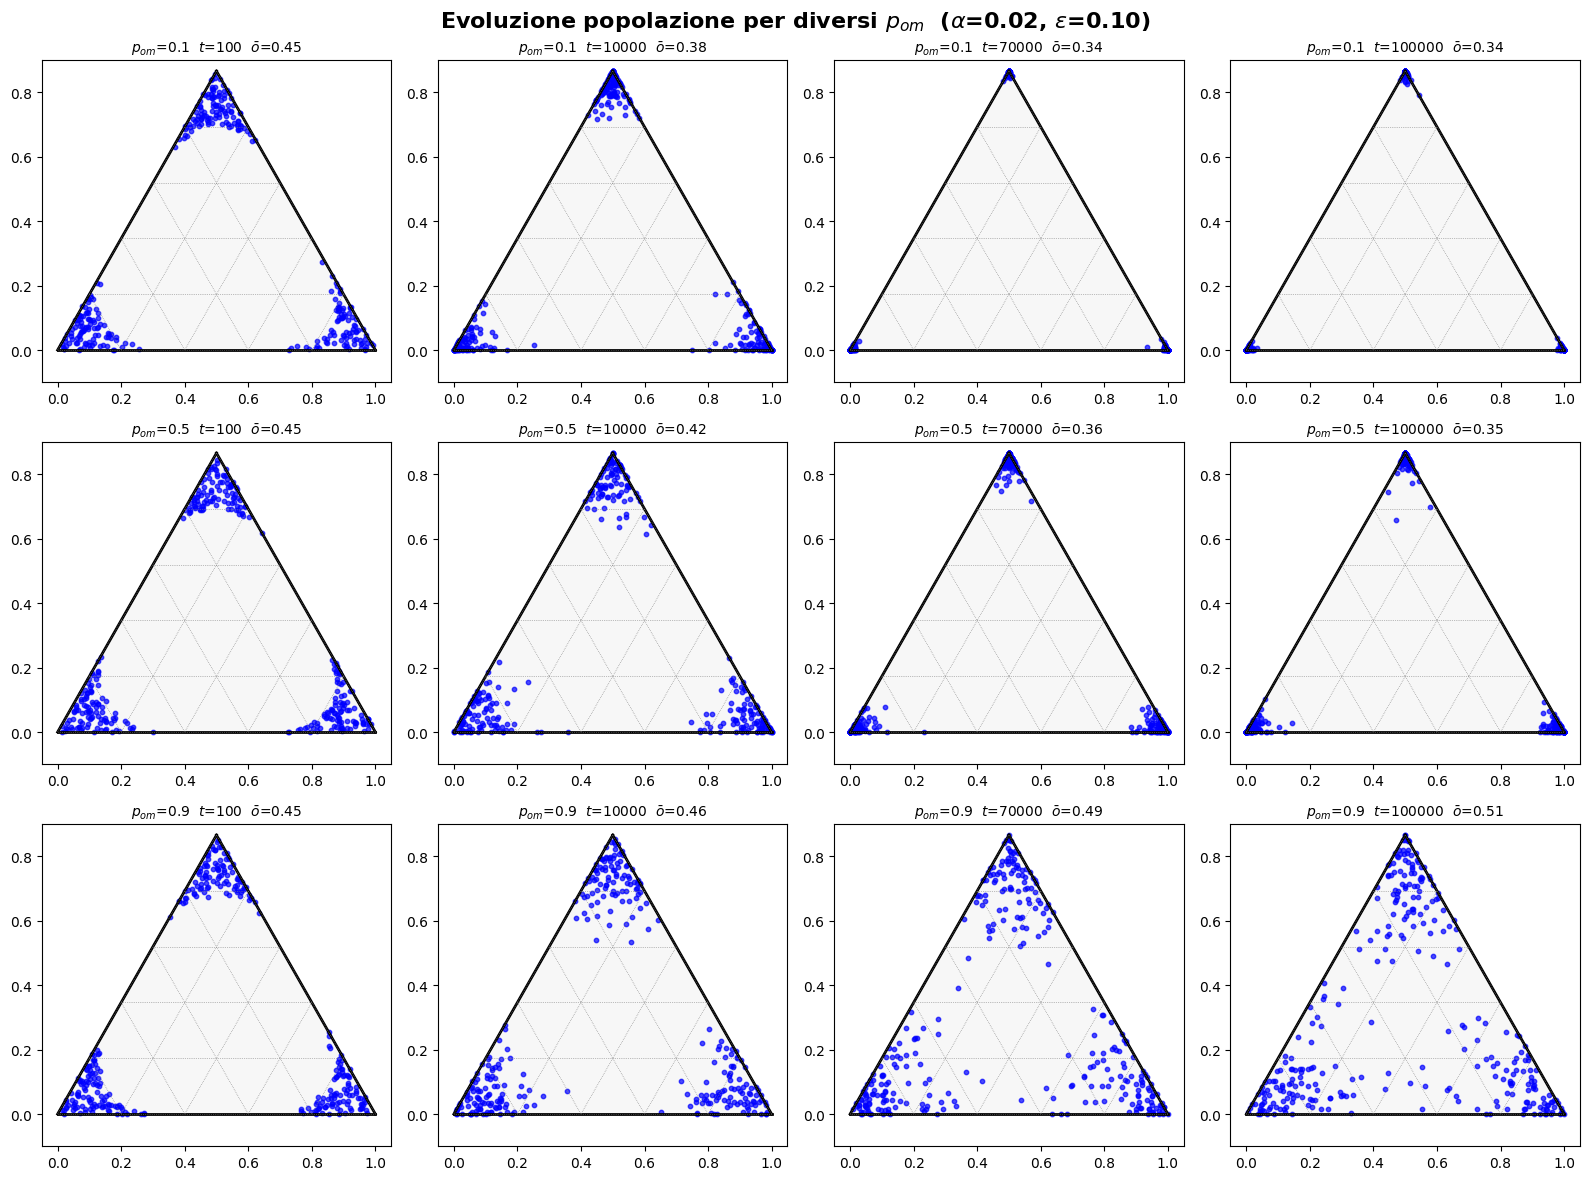

In [6]:
# situa iniziale frammentata

eps = 0.1
times = [100, 10000, 70000, 100000]
p_om_values = [0.1, 0.5, 0.9]
entropy_threshold=0.9
fig, axes = plt.subplots(len(p_om_values), len(times), figsize=(4*len(times), 4*len(p_om_values)))

for i, p_om in enumerate(p_om_values):
    
    # popolazione iniziale (la rigeneriamo per ogni p_om)
    popolazione_iniziale = generate_population(K, N, entropy_threshold)
    
    # evoluzione fino al tempo massimo necessario
    t_max = max(times)
    pop_evoluta, storico, storico_interaction = evolve_population_p_om_fissata(
        popolazione_iniziale, t_max, eps, alpha, p_om
    )
    
    for j, t in enumerate(times):
        
        if t in storico:
            pop_t = storico[t]
        else:
            # se per qualche motivo non è salvato esattamente quel t
            pop_t = storico[min(storico.keys(), key=lambda x: abs(x-t))]
        
        o_t = calculate_total_overlap(pop_t)
        
        plot_simplesso_with_ax(
            pop_t,
            axes[i, j],
            rf"$p_{{om}}$={p_om}  $t$={t}  $\bar{{o}}$={o_t:.2f}"
        )

plt.suptitle(
    rf"Evoluzione popolazione per diversi $p_{{om}}$  ($\alpha$={alpha:.2f}, $\epsilon$={eps:.2f})",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

/Users/camilla/Desktop/Scrivania - MacBook Air di Camilla/DOTTORATO/alice/Cooperation-main/venv/lib/python3.14/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


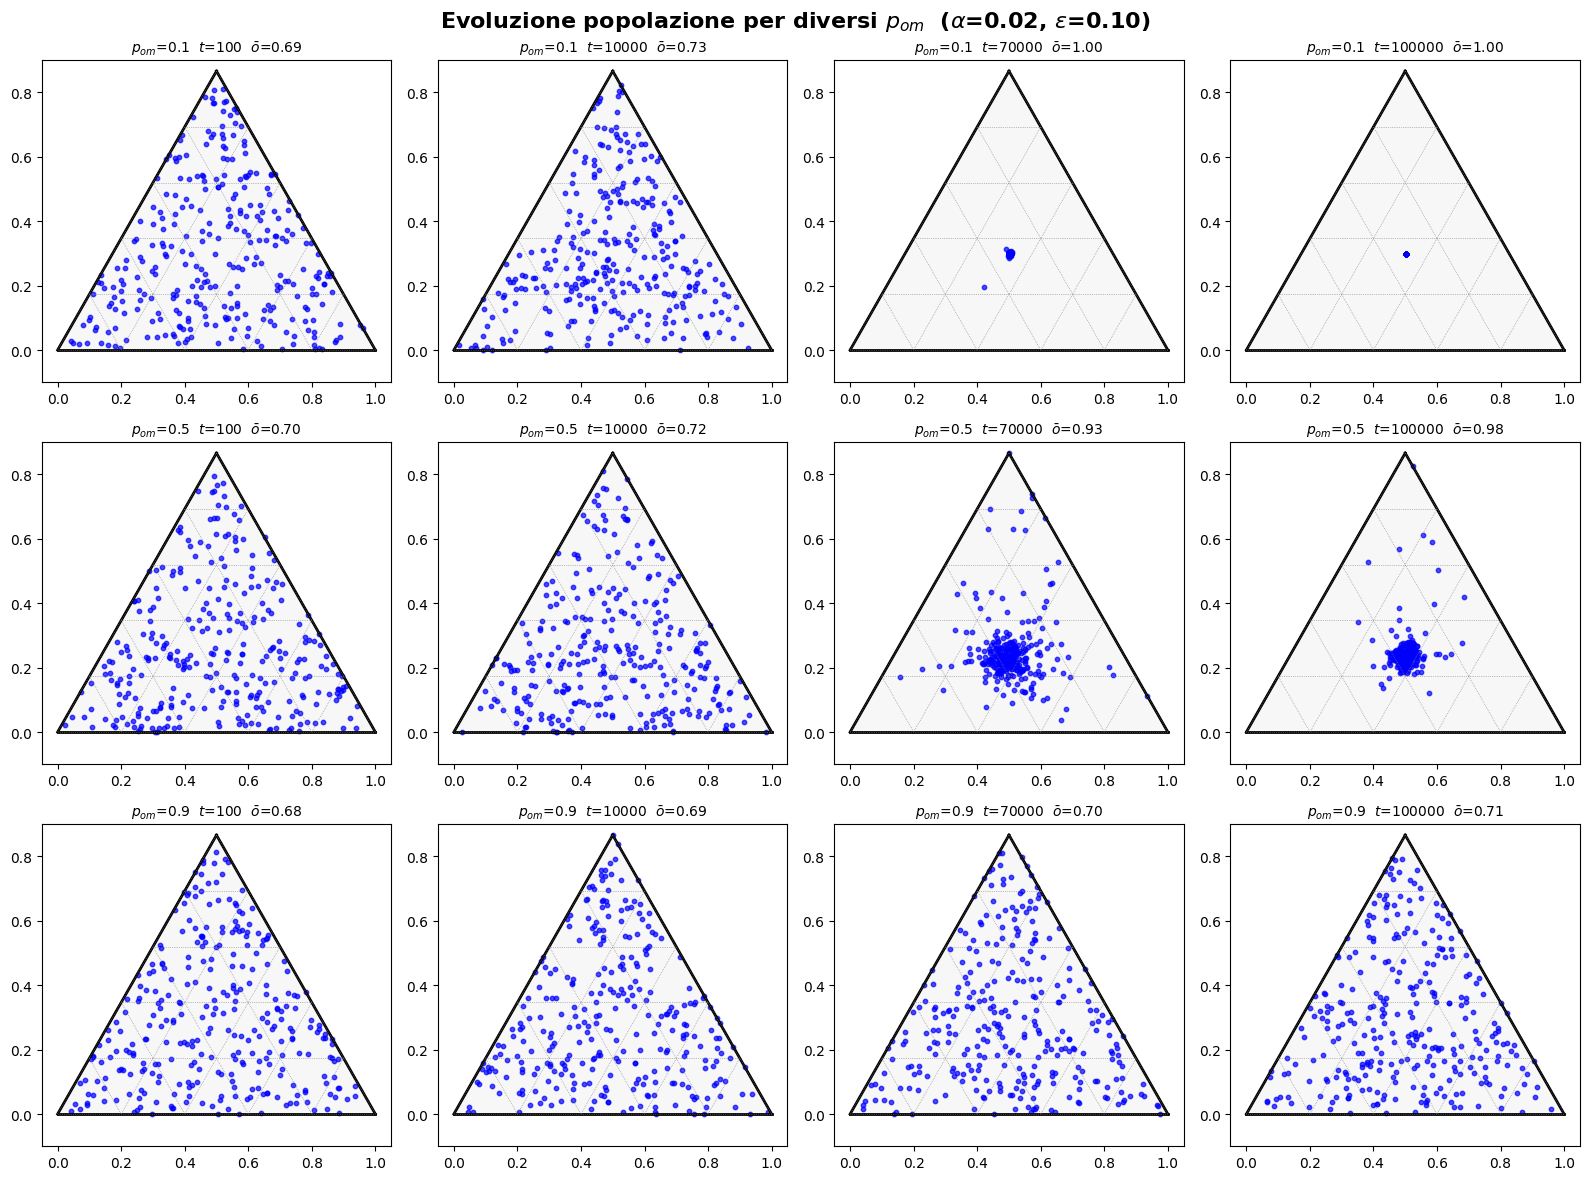

In [7]:
#situa iniziale non frammentata 

entropy_threshold=1.6
eps = 0.1
times = [100, 10000, 70000, 100000]
p_om_values = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(len(p_om_values), len(times), figsize=(4*len(times), 4*len(p_om_values)))

for i, p_om in enumerate(p_om_values):
    
    # popolazione iniziale (la rigeneriamo per ogni p_om)
    popolazione_iniziale = generate_population(K, N, entropy_threshold)
    
    # evoluzione fino al tempo massimo necessario
    t_max = max(times)
    pop_evoluta, storico, storico_interaction = evolve_population_p_om_fissata(
        popolazione_iniziale, t_max, eps, alpha, p_om
    )
    
    for j, t in enumerate(times):
        
        if t in storico:
            pop_t = storico[t]
        else:
            # se per qualche motivo non è salvato esattamente quel t
            pop_t = storico[min(storico.keys(), key=lambda x: abs(x-t))]
        
        o_t = calculate_total_overlap(pop_t)
        
        plot_simplesso_with_ax(
            pop_t,
            axes[i, j],
            rf"$p_{{om}}$={p_om}  $t$={t}  $\bar{{o}}$={o_t:.2f}"
        )

plt.suptitle(
    rf"Evoluzione popolazione per diversi $p_{{om}}$  ($\alpha$={alpha:.2f}, $\epsilon$={eps:.2f})",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# PARTE DI CLUSTERING  

In [8]:
high_overlap = 2.2
low_overlap = 1.6

pop_high = generate_population(5, 100, high_overlap)
pop_low =  generate_population(5 , 100, low_overlap) 

pop_finale_high, storico, storico_int_high = evolve_population_p_om_fissata( pop_high , 100000 , 0.1, 0.02 ,0.5)
pop_finale_low , storico , storico_int_low =evolve_population_p_om_fissata( pop_low  , 100000 , 0.1, 0.02 , 0.5)

labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.2)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.2)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ K 

PR high: 1.0
PR low: 4.7664442326024785


### ORA DEVO AGGIUNGERE EXTERNAL INFORMATION 

In [9]:
PI = 0.5
K = 3
eps = 0.1
alpha = 0.02
time = 100000
entropy_threshold=1.2
pop_iniz = generate_population(K ,100, entropy_threshold)

a_s = []
PR_low = []
m=0  #cambiando questo determino quanto è potente la mild info rispetto alla polarized info. ora 0 significa che c'è solo polarized
p_om=0.5
for a_ in np.arange(0, 1.1, 0.1): #vediamo che cambia al variare della polarizzazione degli esterni
    a_s.append(a_)
    I = external_info(K,a_)
    pop_finale   , storico =  evolve_population_with_pol_info_mild_info_and_peer( pop_iniz , time , eps, alpha , I , PI , m, p_om)
    labels  = hierarchical_clustering_K(pop_finale, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_low.append(pr)
    print('PR for a = ', a_, 'is PR= ', pr)



PR for a =  0.0 is PR=  1.0
PR for a =  0.1 is PR=  1.1496895838123706
PR for a =  0.2 is PR=  1.0
PR for a =  0.30000000000000004 is PR=  1.0
PR for a =  0.4 is PR=  1.0
PR for a =  0.5 is PR=  1.0
PR for a =  0.6000000000000001 is PR=  1.0
PR for a =  0.7000000000000001 is PR=  2.9411764705882355
PR for a =  0.8 is PR=  2.9994001199760048
PR for a =  0.9 is PR=  2.9922202274087373
PR for a =  1.0 is PR=  2.9886431560071727


# Triggering consensus through moderate information

PR for  =  0.0 is PR=  4.835589941972921
PR for  =  0.1 is PR=  4.844961240310077
PR for  =  0.2 is PR=  4.868549172346641
PR for  =  0.30000000000000004 is PR=  4.844961240310077
PR for  =  0.4 is PR=  4.743833017077799
PR for  =  0.5 is PR=  5.393743257820928
PR for  =  0.6000000000000001 is PR=  9.124087591240876
PR for  =  0.7000000000000001 is PR=  1.1544677903486493
PR for  =  0.8 is PR=  1.0201999591920017
PR for  =  0.9 is PR=  1.0
PR for  =  1.0 is PR=  1.0
PR for m =  0.0 is PR=  4.748338081671415
PR for m =  0.1 is PR=  4.761904761904762
PR for m =  0.2 is PR=  4.945598417408506
PR for m =  0.30000000000000004 is PR=  8.169934640522875
PR for m =  0.4 is PR=  3.930817610062893
PR for m =  0.5 is PR=  1.987281399046105
PR for m =  0.6000000000000001 is PR=  1.6345210853220007
PR for m =  0.7000000000000001 is PR=  1.0201999591920017
PR for m =  0.8 is PR=  1.0
PR for m =  0.9 is PR=  1.0
PR for m =  1.0 is PR=  1.0


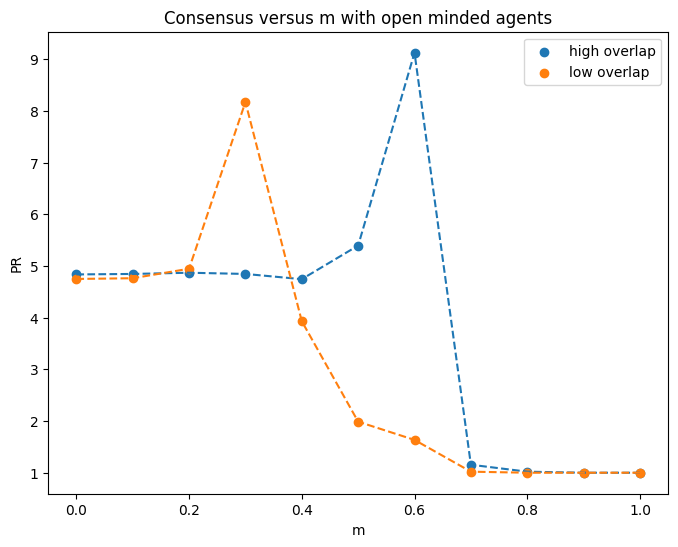

In [10]:
#evolve_population_with_pol_info_mild_info_and_peer
PI = 0.8
K = 5
a = 0.9
eps = 0.1
alpha = 0.02
PR_LOW = []
m_s = []
time = 100000
p_om = 0.5
entropy_threshold=1.4
pop_iniz = generate_population( K ,100, entropy_threshold)# 1.65
I = external_info(K,a)
for m_ in np.arange(0.0, 1.1, 0.1): #variamo m
    pop_finale_low , storico = evolve_population_with_pol_info_mild_info_and_peer( pop_iniz , time , eps, alpha , I , PI , m_, p_om)
    labels  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_LOW.append(pr)
    m_s.append(m_)
    print('PR for  = ', m_, 'is PR= ', pr)


PR_HIGH = []
entropy_threshold= 2.4

pop_iniz = generate_population( K ,100, entropy_threshold)# 2.2
I = external_info(K,a)
for m_ in np.arange(0, 1.1, 0.1):      #m è il potere della fonte mild!
    pop_finale_low , storico = evolve_population_with_pol_info_mild_info_and_peer( pop_iniz , time , eps, alpha , I , PI , m_, p_om)
    labels  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_HIGH.append(pr)
    print('PR for m = ', m_, 'is PR= ', pr)

plt.figure(figsize=(8, 6))
plt.plot(m_s , PR_LOW , '--')
plt.scatter(m_s , PR_LOW , label = 'high overlap')
plt.scatter(m_s , PR_HIGH, label = 'low overlap')
plt.plot(m_s , PR_HIGH , '--' )
plt.xlabel('m')
plt.title('Consensus versus m with open minded agents')
plt.legend()
plt.ylabel('PR')
plt.show()

[FWD] m=0.0  PR=4.770992366412214
[FWD] m=0.1  PR=4.770992366412214
[FWD] m=0.2  PR=4.71253534401508
[FWD] m=0.3  PR=4.71253534401508
[FWD] m=0.4  PR=4.770992366412214
[FWD] m=0.5  PR=4.911591355599215
[FWD] m=0.6  PR=5.307855626326964
[FWD] m=0.7  PR=1.256913021618904
[FWD] m=0.8  PR=1.0
[FWD] m=0.9  PR=1.0
[FWD] m=1.0  PR=1.0
[BWD] m=1.0  PR=1.0
[BWD] m=0.9  PR=1.0
[BWD] m=0.8  PR=1.0
[BWD] m=0.7  PR=1.0
[BWD] m=0.6  PR=1.1049723756906078
[BWD] m=0.5  PR=1.682935038707506
[BWD] m=0.4  PR=1.8726591760299625
[BWD] m=0.3  PR=3.170577045022194
[BWD] m=0.2  PR=6.067961165048544
[BWD] m=0.1  PR=4.496402877697841
[BWD] m=0.0  PR=4.277159965782721


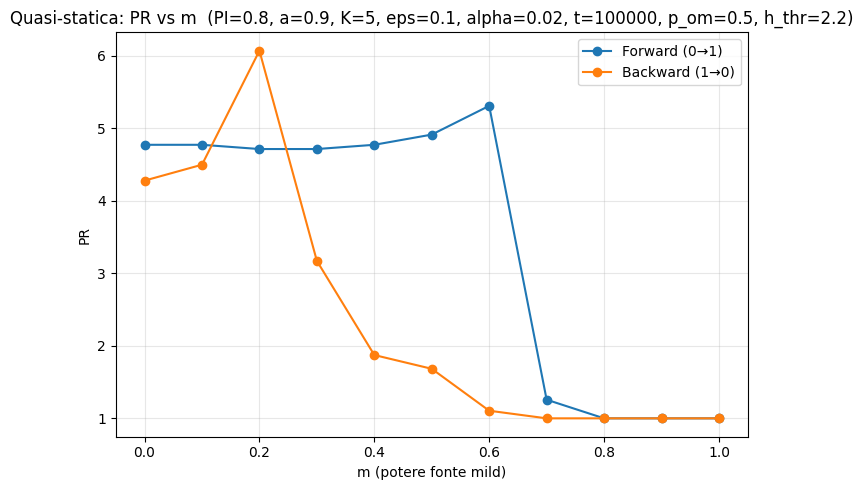

In [11]:
#quasistatica: ISTERESI

PI = 0.8
K = 5
a = 0.9
eps = 0.1
alpha = 0.02
time = 100000
p_om = 0.5
entropy_threshold=2.2

# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)  
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd, m_fwd = [], []
PR_bwd, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")

#plot
plt.figure(figsize=(7,5))
plt.plot(m_fwd, PR_fwd, marker='o', label='Forward (0→1)')
plt.plot(m_bwd, PR_bwd, marker='o', label='Backward (1→0)')
plt.xlabel("m (potere fonte mild)")
plt.ylabel("PR")
plt.title(f"Quasi-statica: PR vs m  (PI={PI}, a={a}, K={K}, eps={eps}, alpha={alpha}, t={time}, p_om={p_om}, h_thr=2.2)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[FWD] m=0.0  PR=4.752851711026616
[FWD] m=0.1  PR=4.752851711026616
[FWD] m=0.2  PR=4.752851711026616
[FWD] m=0.3  PR=4.752851711026616
[FWD] m=0.4  PR=4.752851711026616
[FWD] m=0.5  PR=4.708097928436912
[FWD] m=0.6  PR=6.105006105006105
[FWD] m=0.7  PR=2.423654871546292
[FWD] m=0.8  PR=1.0
[FWD] m=0.9  PR=1.0
[FWD] m=1.0  PR=1.0
[BWD] m=1.0  PR=1.0
[BWD] m=0.9  PR=1.0
[BWD] m=0.8  PR=1.0
[BWD] m=0.7  PR=1.0
[BWD] m=0.6  PR=1.0
[BWD] m=0.5  PR=1.4188422247446084
[BWD] m=0.4  PR=1.9928258270227182
[BWD] m=0.3  PR=2.983293556085919
[BWD] m=0.2  PR=5.924170616113744
[BWD] m=0.1  PR=4.464285714285714
[BWD] m=0.0  PR=4.420866489832007


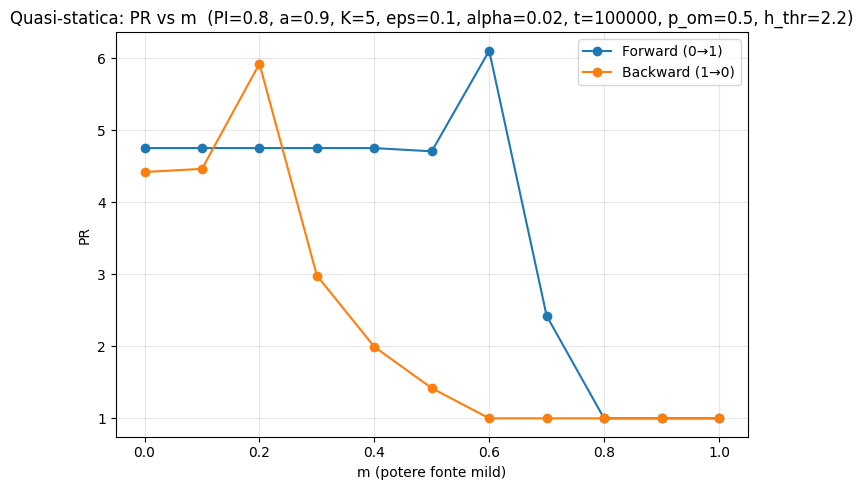

In [18]:
#stessa cella di prima cambio solo overlap iniziale

PI = 0.8
K = 5
a = 0.9
eps = 0.1
alpha = 0.02
time = 100000
p_om = 0.5
entropy_threshold=1.65 

# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)  
pop_iniz=pop_state
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd, m_fwd = [], []
PR_bwd, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")

#plot
plt.figure(figsize=(7,5))
plt.plot(m_fwd, PR_fwd, marker='o', label='Forward (0→1)')
plt.plot(m_bwd, PR_bwd, marker='o', label='Backward (1→0)')
plt.xlabel("m (potere fonte mild)")
plt.ylabel("PR")
plt.title(f"Quasi-statica: PR vs m  (PI={PI}, a={a}, K={K}, eps={eps}, alpha={alpha}, t={time}, p_om={p_om}, h_thr=2.2)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[FWD] m=0.0  PR=2.9886431560071727
[FWD] m=0.1  PR=2.9886431560071727
[FWD] m=0.2  PR=2.9886431560071727
[FWD] m=0.3  PR=2.9886431560071727
[FWD] m=0.4  PR=3.0788177339901477
[FWD] m=0.5  PR=4.091653027823241
[FWD] m=0.6  PR=1.0
[FWD] m=0.7  PR=1.0
[FWD] m=0.8  PR=1.0
[FWD] m=0.9  PR=1.0
[FWD] m=1.0  PR=1.0
[BWD] m=1.0  PR=1.0
[BWD] m=0.9  PR=1.0
[BWD] m=0.8  PR=1.0
[BWD] m=0.7  PR=1.0
[BWD] m=0.6  PR=1.127141568981064
[BWD] m=0.5  PR=1.0
[BWD] m=0.4  PR=1.0
[BWD] m=0.3  PR=2.059308072487644
[BWD] m=0.2  PR=1.3024225058609014
[BWD] m=0.1  PR=1.0838933448948624
[BWD] m=0.0  PR=1.0838933448948624
[FWD] m=0.0  PR=2.97441998810232
[FWD] m=0.1  PR=2.960331557134399
[FWD] m=0.2  PR=2.955082742316785
[FWD] m=0.3  PR=2.963841138114997
[FWD] m=0.4  PR=3.0303030303030303
[FWD] m=0.5  PR=3.2467532467532467
[FWD] m=0.6  PR=1.0
[FWD] m=0.7  PR=1.0
[FWD] m=0.8  PR=1.0
[FWD] m=0.9  PR=1.0
[FWD] m=1.0  PR=1.0
[BWD] m=1.0  PR=1.0
[BWD] m=0.9  PR=1.0
[BWD] m=0.8  PR=1.0
[BWD] m=0.7  PR=1.0
[BWD] m=0.6  

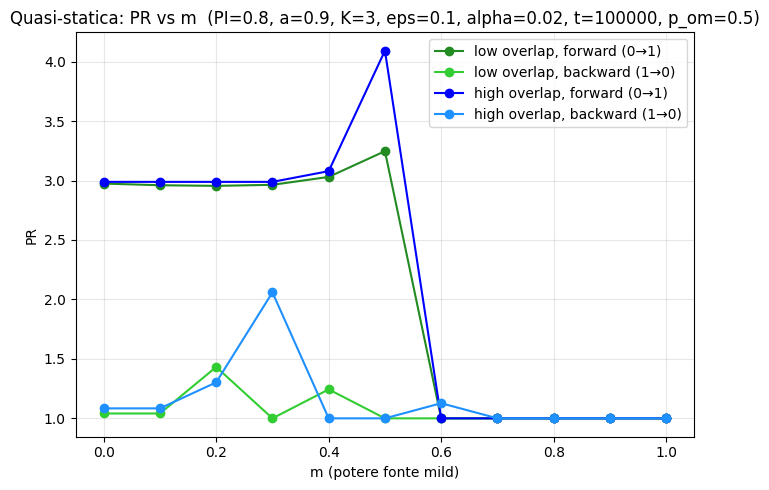

In [55]:
#idem per K=3 metto tutto nella stessa figura overlap alto e basso

import numpy as np
import matplotlib.pyplot as plt

# Parametri (come i tuoi)
PI = 0.8
K = 3
a = 0.9
eps = 0.1
alpha = 0.02
time = 100000
p_om = 0.5
entropy_threshold = 1.6

# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd_high, m_fwd = [], []
PR_bwd_high, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd_high.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd_high.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")


#OVERLAP ALTO
entropy_threshold = 1.4
# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd_low, m_fwd = [], []
PR_bwd_low, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd_low.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd_low.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")

# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(m_fwd, PR_fwd_low, marker='o', label='low overlap, forward (0→1)', c='forestgreen')
plt.plot(m_bwd, PR_bwd_low, marker='o', label='low overlap, backward (1→0)', c='limegreen')
plt.plot(m_fwd, PR_fwd_high, marker='o', label='high overlap, forward (0→1)', c='blue')
plt.plot(m_bwd, PR_bwd_high, marker='o', label='high overlap, backward (1→0)', c='dodgerblue')
plt.xlabel("m (potere fonte mild)")
plt.ylabel("PR")
plt.title(f"Quasi-statica: PR vs m  (PI={PI}, a={a}, K={K}, eps={eps}, alpha={alpha}, t={time}, p_om={p_om})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[FWD] m=0.0  PR=2.736726874657909
[FWD] m=0.1  PR=2.736726874657909
[FWD] m=0.2  PR=2.736726874657909
[FWD] m=0.3  PR=2.736726874657909
[FWD] m=0.4  PR=2.736726874657909
[FWD] m=0.5  PR=2.736726874657909
[FWD] m=0.6  PR=2.721829069134458
[FWD] m=0.7  PR=1.0
[FWD] m=0.8  PR=1.0
[FWD] m=0.9  PR=1.0
[FWD] m=1.0  PR=1.0
[BWD] m=1.0  PR=1.0
[BWD] m=0.9  PR=1.0
[BWD] m=0.8  PR=1.0
[BWD] m=0.7  PR=1.0
[BWD] m=0.6  PR=1.0
[BWD] m=0.5  PR=1.0
[BWD] m=0.4  PR=1.0
[BWD] m=0.3  PR=1.0
[BWD] m=0.2  PR=1.0
[BWD] m=0.1  PR=1.0
[BWD] m=0.0  PR=1.0
[FWD] m=0.0  PR=6.150061500615006
[FWD] m=0.1  PR=6.485084306095979
[FWD] m=0.2  PR=7.204610951008646
[FWD] m=0.3  PR=6.605019815059445
[FWD] m=0.4  PR=6.87757909215956
[FWD] m=0.5  PR=7.788161993769471
[FWD] m=0.6  PR=7.587253414264036
[FWD] m=0.7  PR=6.944444444444445
[FWD] m=0.8  PR=6.090133982947624
[FWD] m=0.9  PR=4.488330341113106
[FWD] m=1.0  PR=5.875440658049354
[BWD] m=1.0  PR=5.555555555555555
[BWD] m=0.9  PR=5.482456140350878
[BWD] m=0.8  PR=6.858

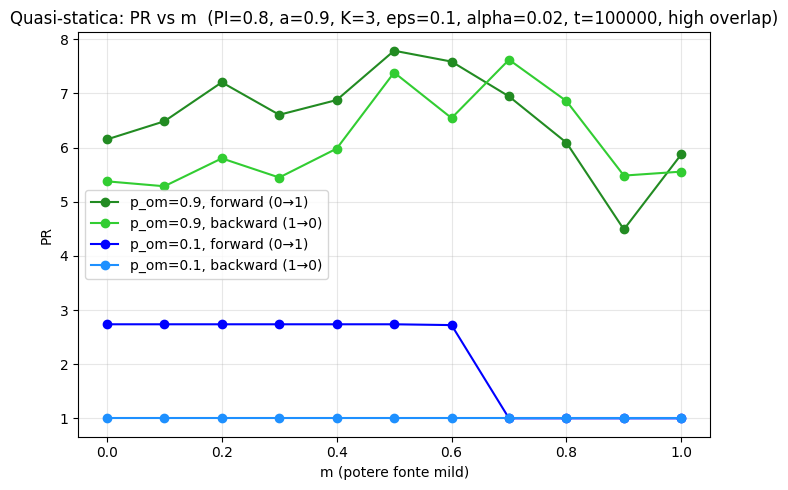

In [14]:
# ora provo con diversi valori di p_om
PI = 0.8
K = 3
a = 0.9
eps = 0.1
alpha = 0.02
time = 100000
p_om = 0.1
entropy_threshold = 1.6

# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd_high, m_fwd = [], []
PR_bwd_high, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd_high.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd_high.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")

p_om = 0.9

# Stato iniziale
pop_state = generate_population(K, 100, entropy_threshold)
I = external_info(K, a)

# Griglia m
m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
m_grid_bwd = m_grid_fwd[::-1]

PR_fwd_low, m_fwd = [], []
PR_bwd_low, m_bwd = [], []

# --- FORWARD: 0 -> 1 ---
for m_ in m_grid_fwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_fwd_low.append(pr)
    m_fwd.append(float(m_))
    print(f"[FWD] m={m_:.1f}  PR={pr}")

# Salvo lo stato a m=1 per ripartenza backward (opzionale, ma chiaro)
pop_state_at_1 = pop_state

# --- BACKWARD: 1 -> 0 ---
pop_state = pop_state_at_1
for m_ in m_grid_bwd:
    pop_state, storico = evolve_population_with_pol_info_mild_info_and_peer(
        pop_state, time, eps, alpha, I, PI, float(m_), p_om
    )
    labels = hierarchical_clustering_K(pop_state, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_bwd_low.append(pr)
    m_bwd.append(float(m_))
    print(f"[BWD] m={m_:.1f}  PR={pr}")

# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(m_fwd, PR_fwd_low, marker='o', label='p_om=0.9, forward (0→1)', c='forestgreen')
plt.plot(m_bwd, PR_bwd_low, marker='o', label='p_om=0.9, backward (1→0)', c='limegreen')
plt.plot(m_fwd, PR_fwd_high, marker='o', label='p_om=0.1, forward (0→1)', c='blue')
plt.plot(m_bwd, PR_bwd_high, marker='o', label='p_om=0.1, backward (1→0)', c='dodgerblue')
plt.xlabel("m (potere fonte mild)")
plt.ylabel("PR")
plt.title(f"Quasi-statica: PR vs m  (PI={PI}, a={a}, K={K}, eps={eps}, alpha={alpha}, t={time}, high overlap)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

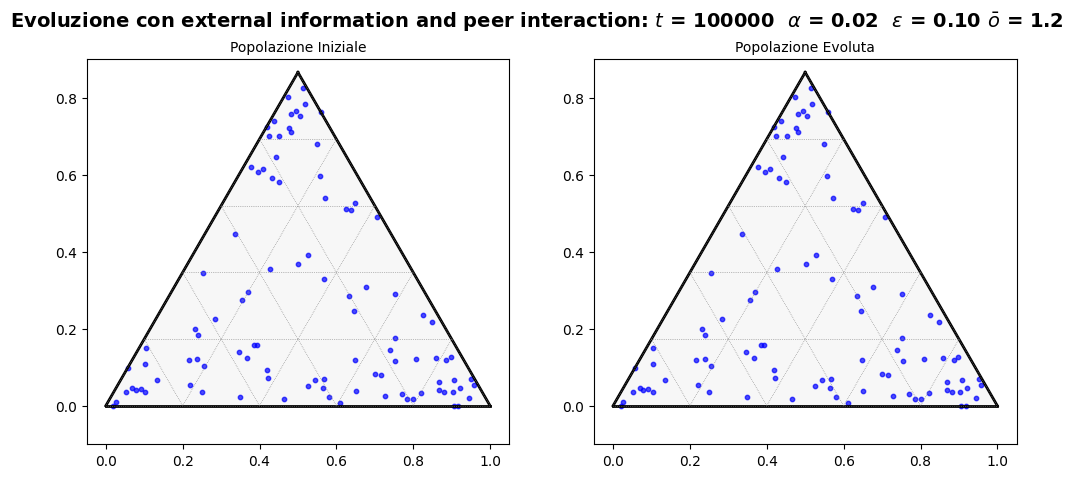

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
plt.suptitle(rf"Evoluzione con external information and peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} $\bar{{o}}$ = 1.2", fontsize=14,  fontweight='bold')
plot_simplesso_with_ax(pop_state, axes[0], "Popolazione Iniziale")
plot_simplesso_with_ax(pop_state, axes[1], "Popolazione Evoluta")

## LE SEGUENTI CELLE SONO M DA 0 A 1 E DA 1 A 0 QUASISTATICA, OGNI CELLA PER UN DIVERSO VALORE DI P_OM DA 0.9 A 0.1, PARTENDO DA ALTO OVERLAP

In [44]:
#funzione gigante fatta da chat per non riscrivere mille volte la stessa cosa... dovrebbe essere giusta.

import numpy as np
import matplotlib.pyplot as plt

def run_quasistatic_m_sweep(
    PI=0.8,
    K=3,
    N=100,
    a=0.9,
    eps=0.1,
    alpha=0.02,
    time=100000,
    entropy_threshold=1.6,
    p_om=0.3,
    similarity_threshold=0.8,
    m_grid=None,
    make_plots=True,
    figsize_grid=None,
    figsize_pr=(7, 5),
    return_data=True,
):
    """
    Esegue sweep quasi-statico in m: forward (0→1) e backward (1→0),
    salva stati finali per ogni m e calcola PR via hierarchical_clustering_K + compute_PR.
    Produce:
      - griglia 2 x len(m) di simplessi (FWD/BWD) in ordine crescente di m
      - plot PR vs m (FWD/BWD; entrambi con ascissa crescente se vuoi)
    """

    if m_grid is None:
        m_grid_fwd = np.round(np.arange(0, 1.0 + 1e-9, 0.1), 2)
    else:
        m_grid_fwd = np.array(m_grid, dtype=float)
    m_grid_bwd = m_grid_fwd[::-1]

    # stato iniziale
    pop_state = generate_population(K, N, entropy_threshold)
    I = external_info(K, a)

    states_fwd, PR_fwd = [], []
    states_bwd, PR_bwd = [], []

    # -------- FORWARD 0 → 1 --------
    for m_ in m_grid_fwd:
        pop_state, _ = evolve_population_with_pol_info_mild_info_and_peer(
            pop_state, time, eps, alpha, I, PI, float(m_), p_om
        )
        pop_copy = pop_state.copy()
        states_fwd.append(pop_copy)

        labels = hierarchical_clustering_K(pop_copy, similarity_threshold=similarity_threshold)
        PR_fwd.append(compute_PR(labels))

    pop_state_at_1 = pop_state.copy()

    # -------- BACKWARD 1 → 0 --------
    pop_state = pop_state_at_1

    for m_ in m_grid_bwd:
        pop_state, _ = evolve_population_with_pol_info_mild_info_and_peer(
            pop_state, time, eps, alpha, I, PI, float(m_), p_om
        )
        pop_copy = pop_state.copy()
        states_bwd.append(pop_copy)

        labels = hierarchical_clustering_K(pop_copy, similarity_threshold=similarity_threshold)
        PR_bwd.append(compute_PR(labels))

    # riordino backward in senso crescente di m (così allinei colonne e anche PR)
    states_bwd_inc = states_bwd[::-1]
    PR_bwd_inc = PR_bwd[::-1]

    # =========================
    # FIGURA 1: GRID SIMPLesso
    # =========================
    if make_plots:
        if figsize_grid is None:
            figsize_grid = (3 * len(m_grid_fwd), 6)

        fig, axes = plt.subplots(2, len(m_grid_fwd), figsize=figsize_grid)

        for j, m_ in enumerate(m_grid_fwd):
            o_fwd = calculate_total_overlap(states_fwd[j])
            plot_simplesso_with_ax(
                states_fwd[j],
                axes[0, j],
                rf"FWD  m={m_:.1f}  $\bar{{o}}$={o_fwd:.2f}"
            )

            o_bwd = calculate_total_overlap(states_bwd_inc[j])
            plot_simplesso_with_ax(
                states_bwd_inc[j],
                axes[1, j],
                rf"BWD  m={m_:.1f}  $\bar{{o}}$={o_bwd:.2f}"
            )

        plt.suptitle(
            rf"Quasi-statica in m  ($p_{{om}}$={p_om},  $\alpha$={alpha},  $\epsilon$={eps})",
            fontsize=16,
            fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        # =========================
        # FIGURA 2: PR vs m
        # =========================
        plt.figure(figsize=figsize_pr)
        plt.plot(m_grid_fwd, PR_fwd, marker='o', label='forward (0→1)')
        plt.plot(m_grid_fwd, PR_bwd_inc, marker='o', label='backward (1→0)')
        plt.xlabel("m (potere fonte mild)")
        plt.ylabel("PR")
        plt.title(rf"PR vs m  ($p_{{om}}$={p_om},  sim\_thr={similarity_threshold})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    if return_data:
        return {
            "m_grid": m_grid_fwd,
            "states_fwd": states_fwd,
            "states_bwd": states_bwd_inc,   # già in ordine crescente
            "PR_fwd": np.array(PR_fwd, dtype=float),
            "PR_bwd": np.array(PR_bwd_inc, dtype=float),  # già in ordine crescente
            "pop_state_at_1": pop_state_at_1,
        }
    return None

/Users/camilla/Desktop/Scrivania - MacBook Air di Camilla/DOTTORATO/alice/Cooperation-main/venv/lib/python3.14/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


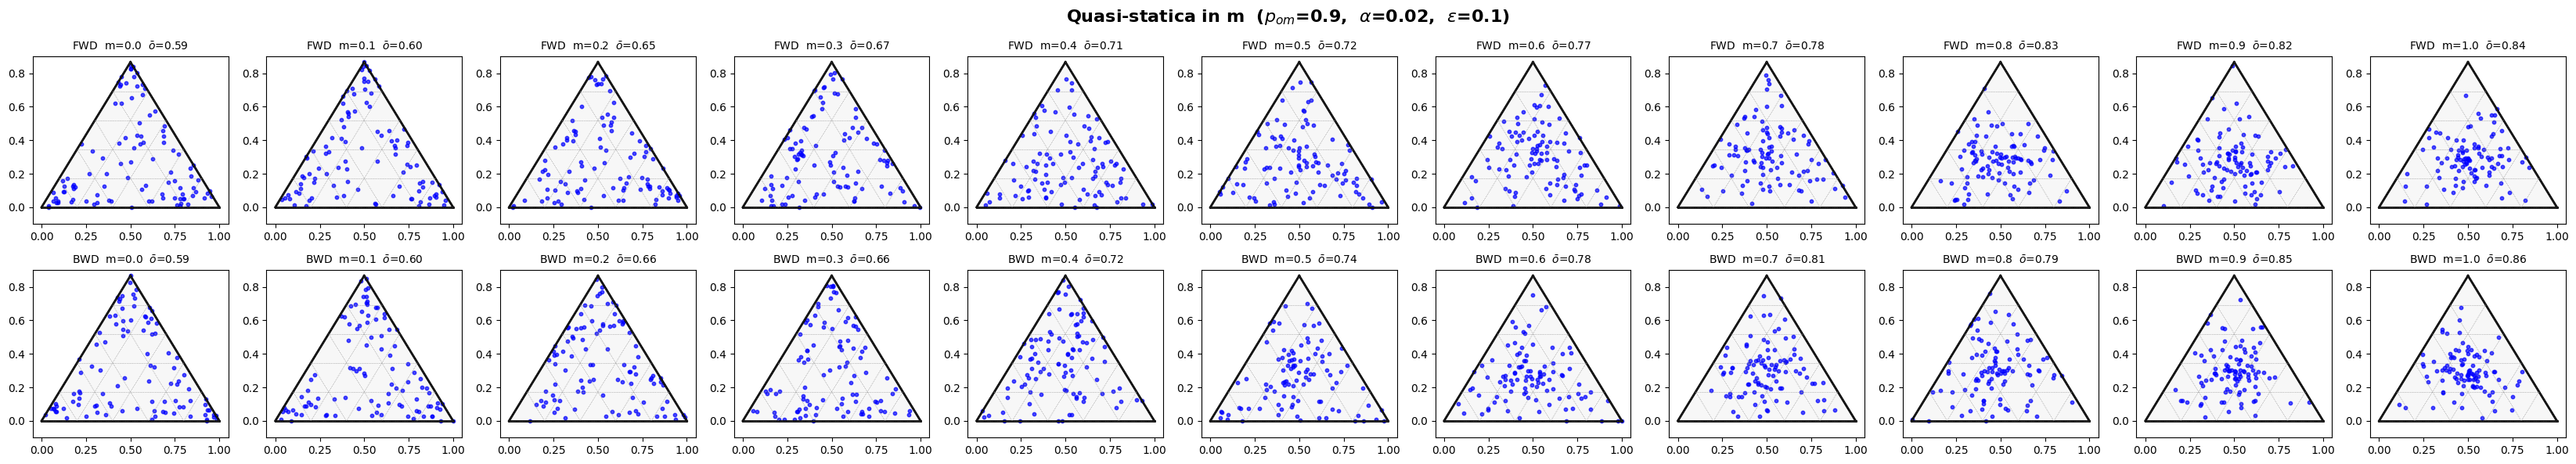

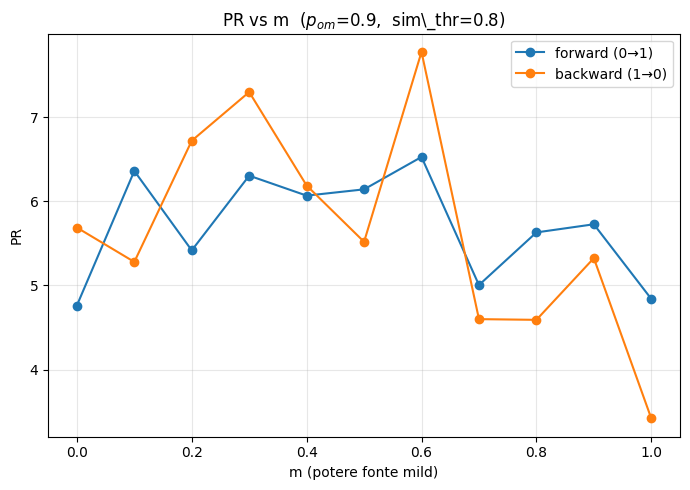

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[0.65230195, 0.0625    , 0.28519805],
         [0.34702201, 0.44741084, 0.20556715],
         [0.09086103, 0.71897015, 0.19016882],
         [0.1800139 , 0.77786274, 0.04212337],
         [0.37187184, 0.0415625 , 0.58656566],
         [0.71316137, 0.06617348, 0.22066515],
         [0.33851709, 0.43445164, 0.22703128],
         [0.81445349, 0.10818436, 0.07736215],
         [0.50317943, 0.1209695 , 0.37585107],
         [0.54463676, 0.39352429, 0.06183895],
         [0.69952009, 0.27032568, 0.03015424],
         [0.07286079, 0.1061563 , 0.82098291],
         [0.01627803, 0.10122858, 0.88249339],
         [0.14555454, 0.84444546, 0.01      ],
         [0.51002102, 0.15060643, 0.33937255],
         [0.06862488, 0.89947927, 0.03189585],
         [0.41660068, 0.52736406, 0.05603526],
         [0.21694403, 0.44130153, 0.34175444],
         [0.07552363, 0.92447637, 0.        ],
         [0.881878

In [45]:

# =========================
# PARAMETRI
# =========================
PI = 0.8
K = 3
N = 100
a = 0.9
eps = 0.1
alpha = 0.02
time = 100000
similarity_threshold=0.8


entropy_threshold = 1.6
p_om = 0.9   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

/Users/camilla/Desktop/Scrivania - MacBook Air di Camilla/DOTTORATO/alice/Cooperation-main/venv/lib/python3.14/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


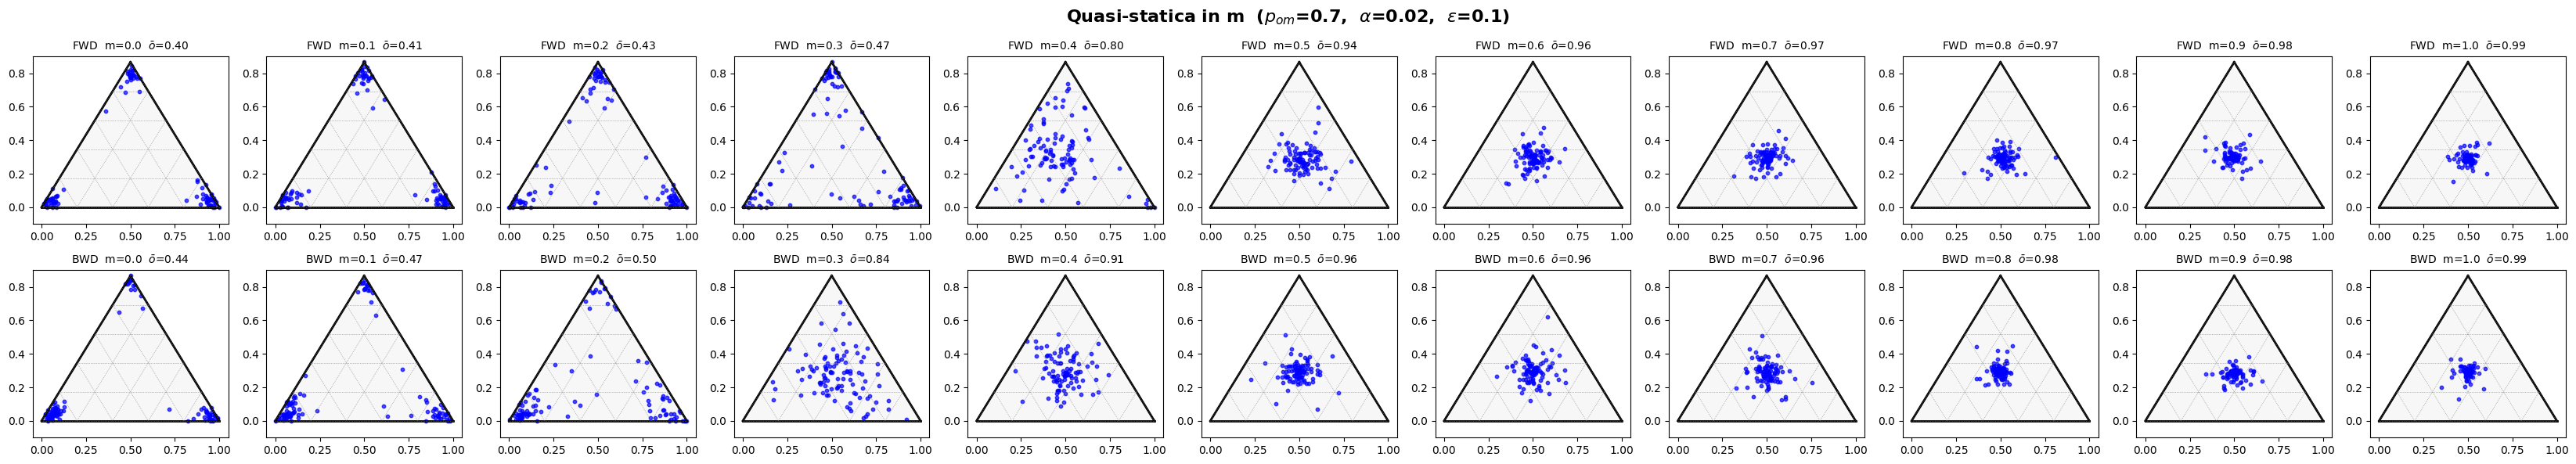

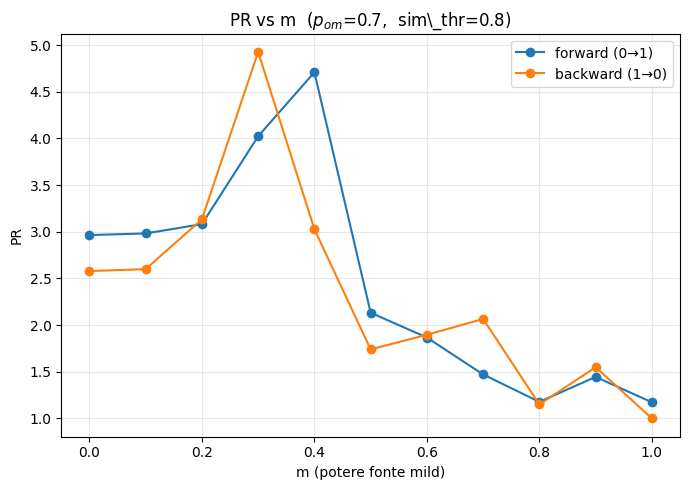

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[8.44469135e-01, 1.55530865e-01, 0.00000000e+00],
         [5.68802759e-02, 9.13543030e-01, 2.95766943e-02],
         [8.63365291e-01, 8.89524433e-02, 4.76822655e-02],
         [9.71250000e-01, 0.00000000e+00, 2.87500000e-02],
         [5.39476838e-02, 8.96006208e-01, 5.00461080e-02],
         [0.00000000e+00, 5.75065729e-02, 9.42493427e-01],
         [5.43503443e-02, 9.09083361e-01, 3.65662947e-02],
         [3.12582127e-02, 3.00000000e-02, 9.38741787e-01],
         [9.12759117e-01, 3.01761583e-02, 5.70647250e-02],
         [5.83966860e-02, 2.22174268e-02, 9.19385887e-01],
         [1.00000000e+00, 9.36750677e-17, 0.00000000e+00],
         [4.00050223e-02, 9.10562353e-01, 4.94326249e-02],
         [9.14106396e-01, 8.39261339e-02, 1.96747048e-03],
         [0.00000000e+00, 4.88941549e-02, 9.51105845e-01],
         [4.13041094e-02, 9.45099032e-01, 1.35968585e-02],
         [9.65258757e-01, 

In [46]:
entropy_threshold = 1.6
p_om = 0.7   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

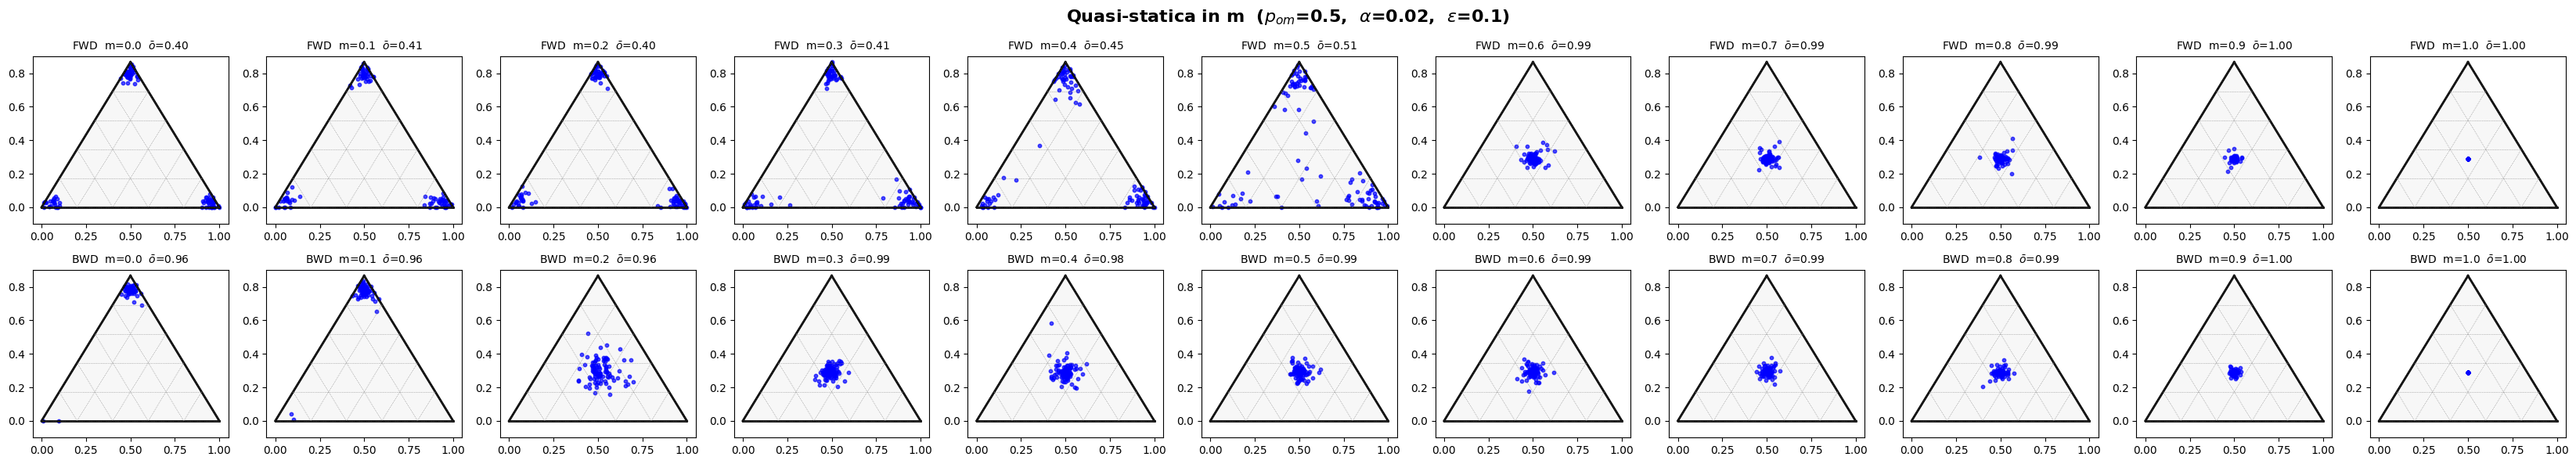

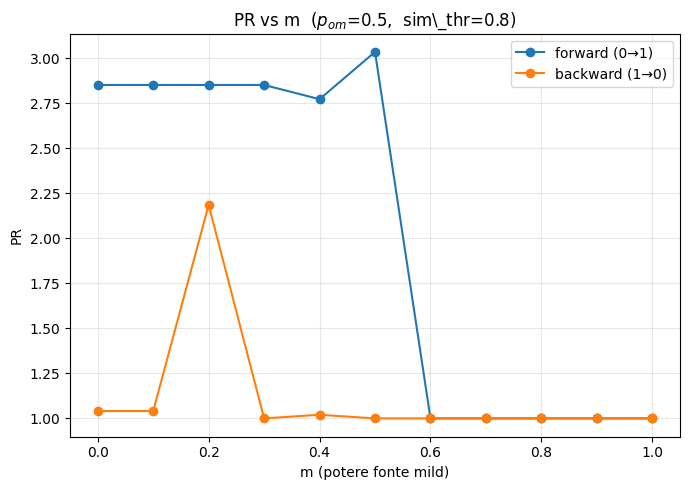

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[7.51873722e-03, 9.15942637e-01, 7.65386253e-02],
         [5.12359224e-02, 4.17407072e-02, 9.07023370e-01],
         [9.80966869e-04, 3.73076037e-02, 9.61711429e-01],
         [9.14202674e-01, 3.57893183e-02, 5.00080078e-02],
         [4.95624736e-02, 9.20151980e-01, 3.02855463e-02],
         [4.53090253e-02, 9.09991616e-01, 4.46993590e-02],
         [8.65046952e-02, 0.00000000e+00, 9.13495305e-01],
         [8.84518738e-01, 4.00000000e-02, 7.54812622e-02],
         [4.15672506e-02, 5.16114216e-02, 9.06821328e-01],
         [9.93104678e-02, 8.50689532e-01, 5.00000000e-02],
         [1.00000000e-02, 9.30659616e-01, 5.93403843e-02],
         [9.65851354e-01, 7.01343753e-03, 2.71352080e-02],
         [9.31038229e-01, 6.89617706e-02, 0.00000000e+00],
         [6.10211933e-02, 5.62644638e-02, 8.82714343e-01],
         [7.67096779e-02, 0.00000000e+00, 9.23290322e-01],
         [1.00000000e+00, 

In [47]:
entropy_threshold = 1.6
p_om = 0.5   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

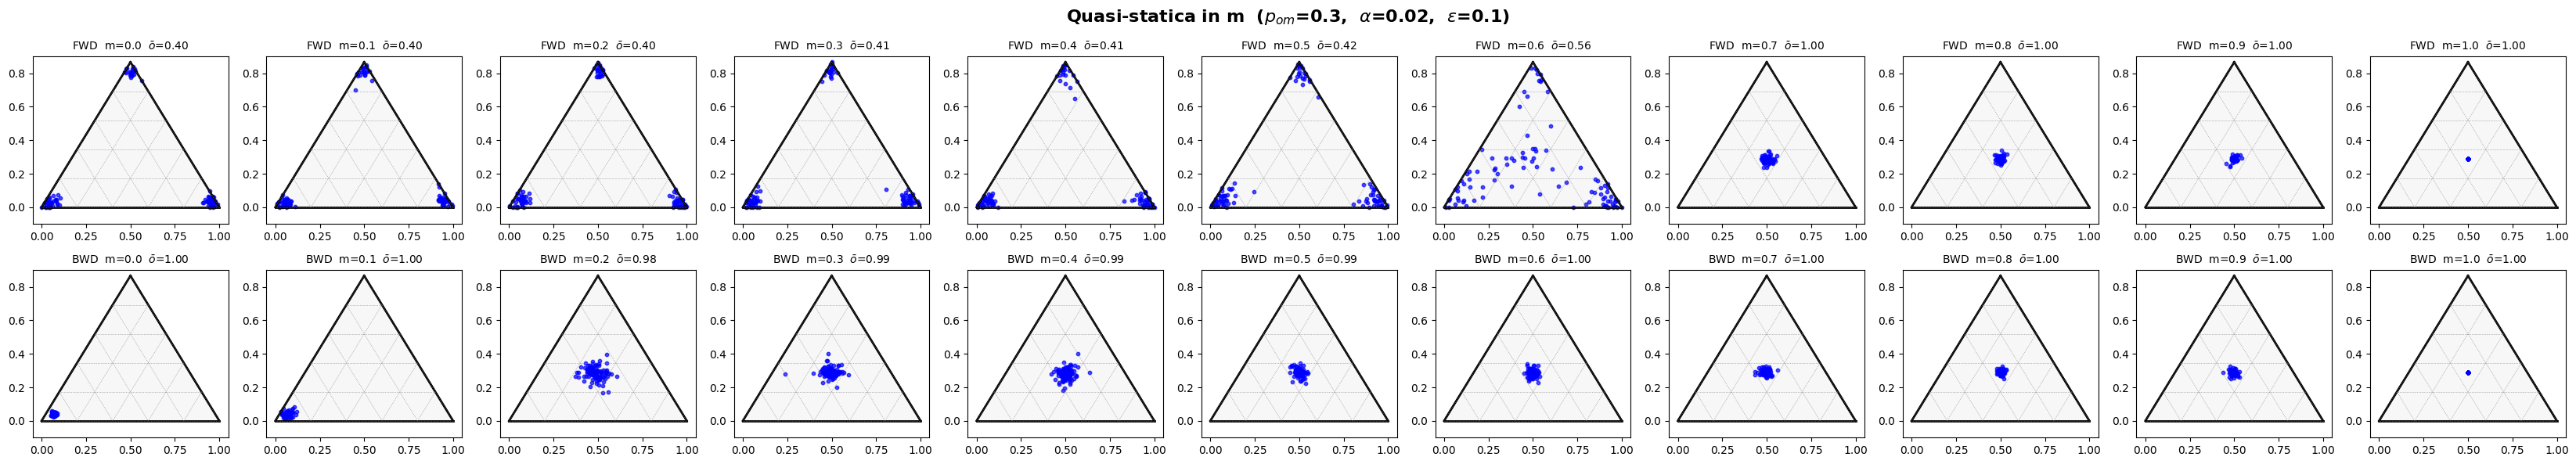

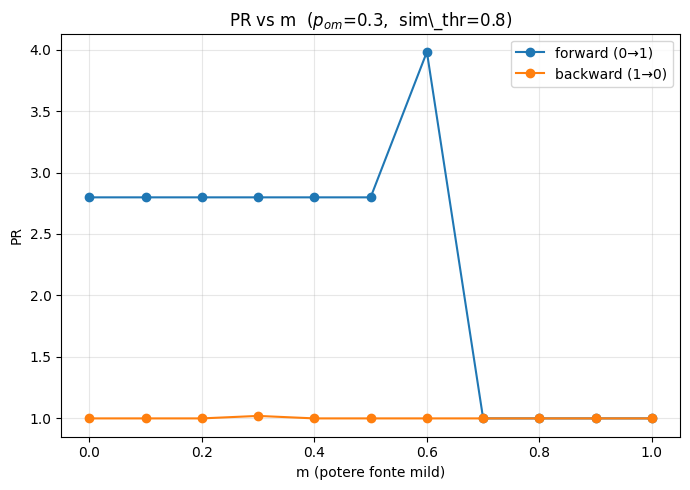

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[1.66066022e-02, 3.38099296e-02, 9.49583468e-01],
         [4.44919524e-02, 9.38262071e-01, 1.72459762e-02],
         [5.79570026e-02, 5.37874174e-02, 8.88255580e-01],
         [9.39405713e-01, 3.33010193e-02, 2.72932678e-02],
         [4.41332687e-02, 9.55866731e-01, 0.00000000e+00],
         [4.65109159e-02, 3.91075113e-03, 9.49578333e-01],
         [4.32615976e-02, 0.00000000e+00, 9.56738402e-01],
         [2.00000000e-02, 0.00000000e+00, 9.80000000e-01],
         [9.25069149e-01, 4.00000000e-02, 3.49308510e-02],
         [1.38138432e-02, 4.44586665e-02, 9.41727490e-01],
         [8.88355506e-01, 1.11644494e-01, 0.00000000e+00],
         [0.00000000e+00, 2.26695405e-02, 9.77330460e-01],
         [4.56696838e-02, 9.15515718e-01, 3.88145985e-02],
         [4.69086928e-02, 4.08980182e-02, 9.12193289e-01],
         [9.19731493e-01, 5.66250161e-02, 2.36434908e-02],
         [3.28553560e-02, 

In [48]:
entropy_threshold = 1.6
p_om = 0.3   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

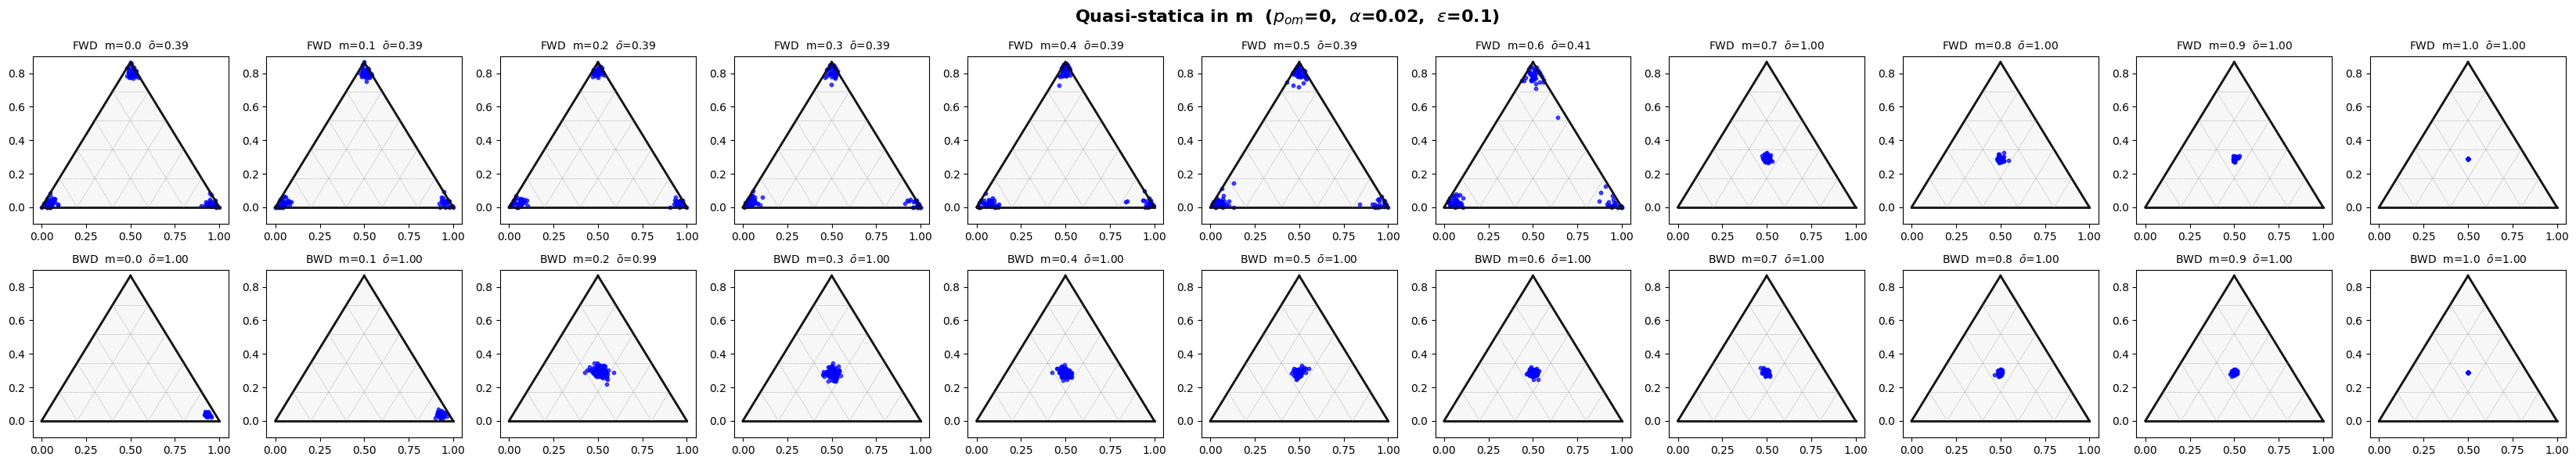

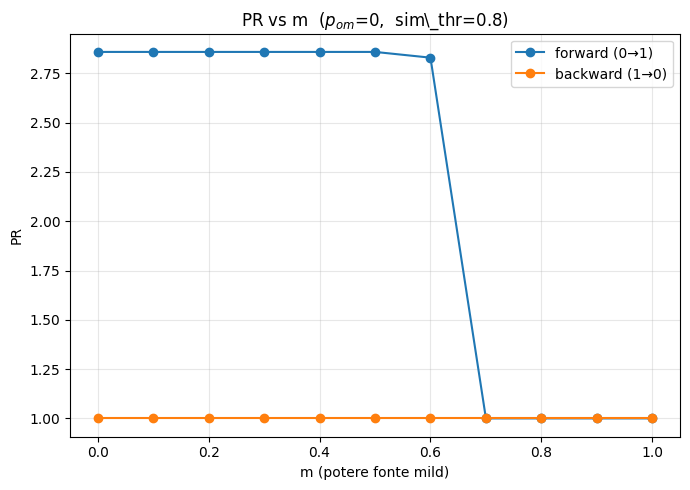

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[4.59839497e-02, 5.13321589e-02, 9.02683891e-01],
         [9.38734811e-01, 1.54456182e-02, 4.58195709e-02],
         [4.20301346e-02, 1.65064030e-02, 9.41463462e-01],
         [3.24475148e-02, 9.47519872e-01, 2.00326135e-02],
         [4.01645795e-02, 9.06053808e-01, 5.37816128e-02],
         [9.30818227e-01, 4.26969343e-02, 2.64848384e-02],
         [1.25745261e-02, 4.56366422e-02, 9.41788832e-01],
         [1.66516849e-02, 3.00000000e-02, 9.53348315e-01],
         [2.42243566e-02, 9.33311452e-01, 4.24641914e-02],
         [9.12717562e-01, 1.31443848e-02, 7.41380535e-02],
         [2.83292961e-02, 4.00242232e-02, 9.31646481e-01],
         [2.72470939e-02, 9.05644996e-01, 6.71079099e-02],
         [2.90697260e-03, 9.61279082e-01, 3.58139452e-02],
         [9.57112560e-01, 2.00000000e-02, 2.28874401e-02],
         [8.98515618e-01, 9.51953516e-02, 6.28903053e-03],
         [5.00000000e-02, 

In [49]:
entropy_threshold = 1.6
p_om = 0   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

## ORA STESSA COSA MA PARTO DA BASSO OVERLAP: M DA 0 A 1 E DA 1 A 0 QUASISTATICA, OGNI CELLA PER UN DIVERSO VALORE DI P_OM DA 0.9 A 0.1

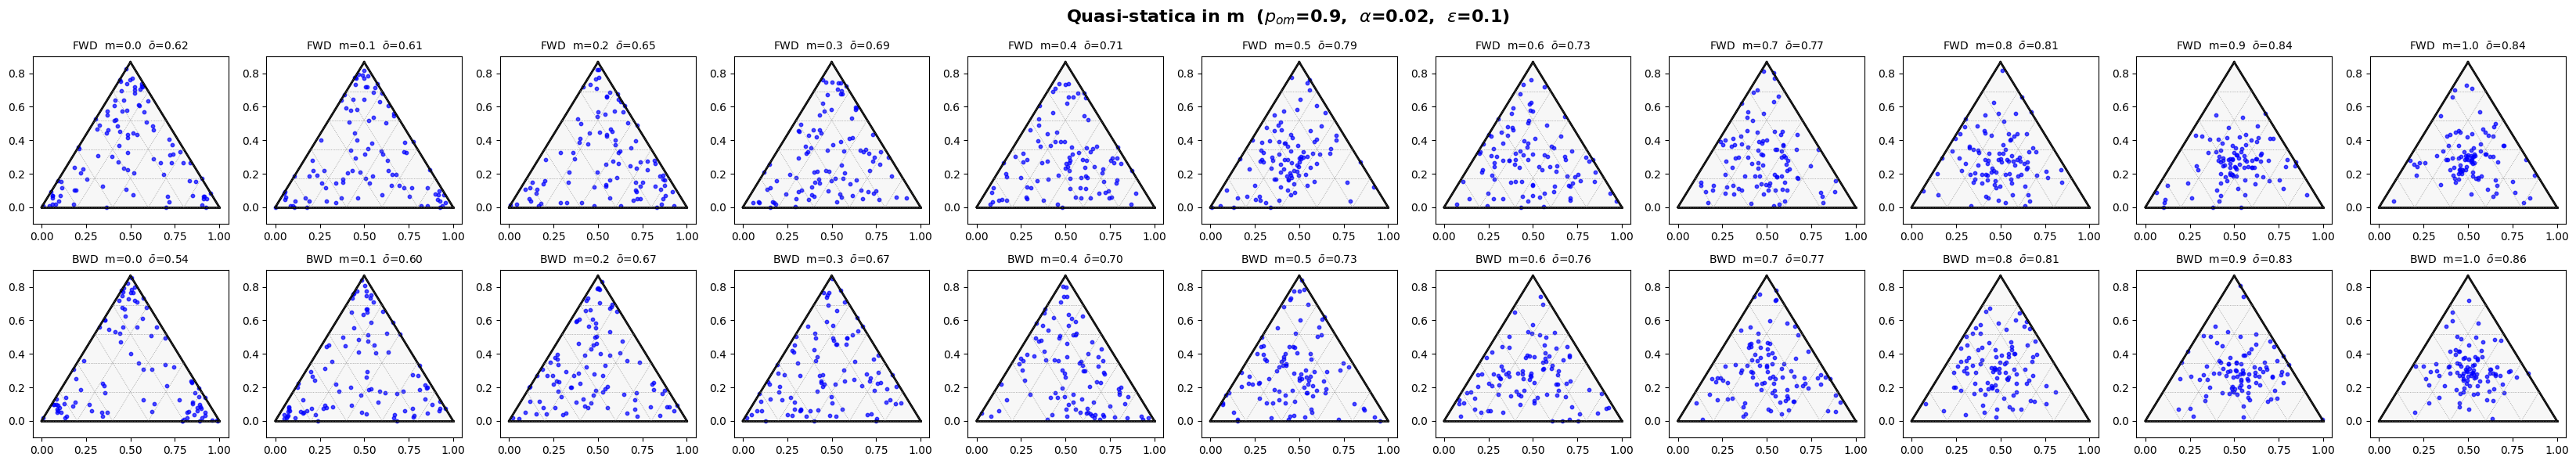

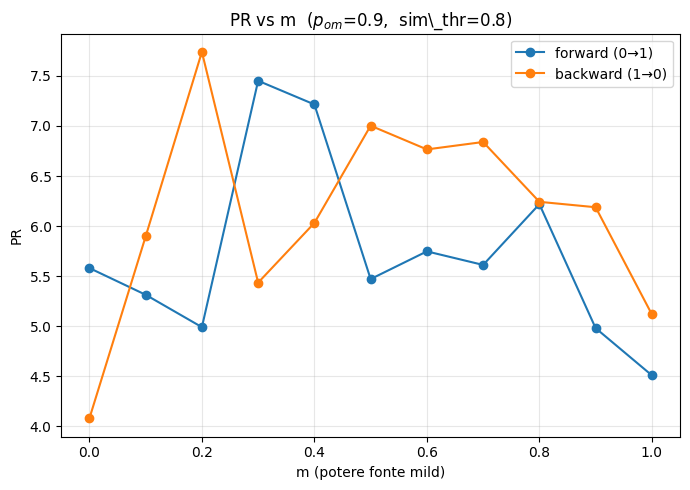

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[0.27150333, 0.14384149, 0.58465519],
         [0.11099991, 0.51190142, 0.37709867],
         [0.1238258 , 0.11918244, 0.75699176],
         [0.17983758, 0.52113366, 0.29902876],
         [0.10885165, 0.59732178, 0.29382657],
         [0.2931908 , 0.37807358, 0.32873562],
         [0.29605909, 0.58769658, 0.11624433],
         [0.        , 0.18139162, 0.81860838],
         [0.05      , 0.27196633, 0.67803367],
         [0.55497141, 0.36752859, 0.0775    ],
         [0.92258247, 0.        , 0.07741753],
         [0.13594449, 0.11694197, 0.74711355],
         [0.14808431, 0.55883856, 0.29307713],
         [0.04733927, 0.80434995, 0.14831078],
         [0.54081821, 0.35810784, 0.10107394],
         [0.13204195, 0.78581975, 0.0821383 ],
         [0.14498805, 0.81501195, 0.04      ],
         [0.09226949, 0.73606392, 0.17166658],
         [0.89870613, 0.06107822, 0.04021564],
         [0.108574

In [50]:
entropy_threshold = 1.4
p_om = 0.9   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

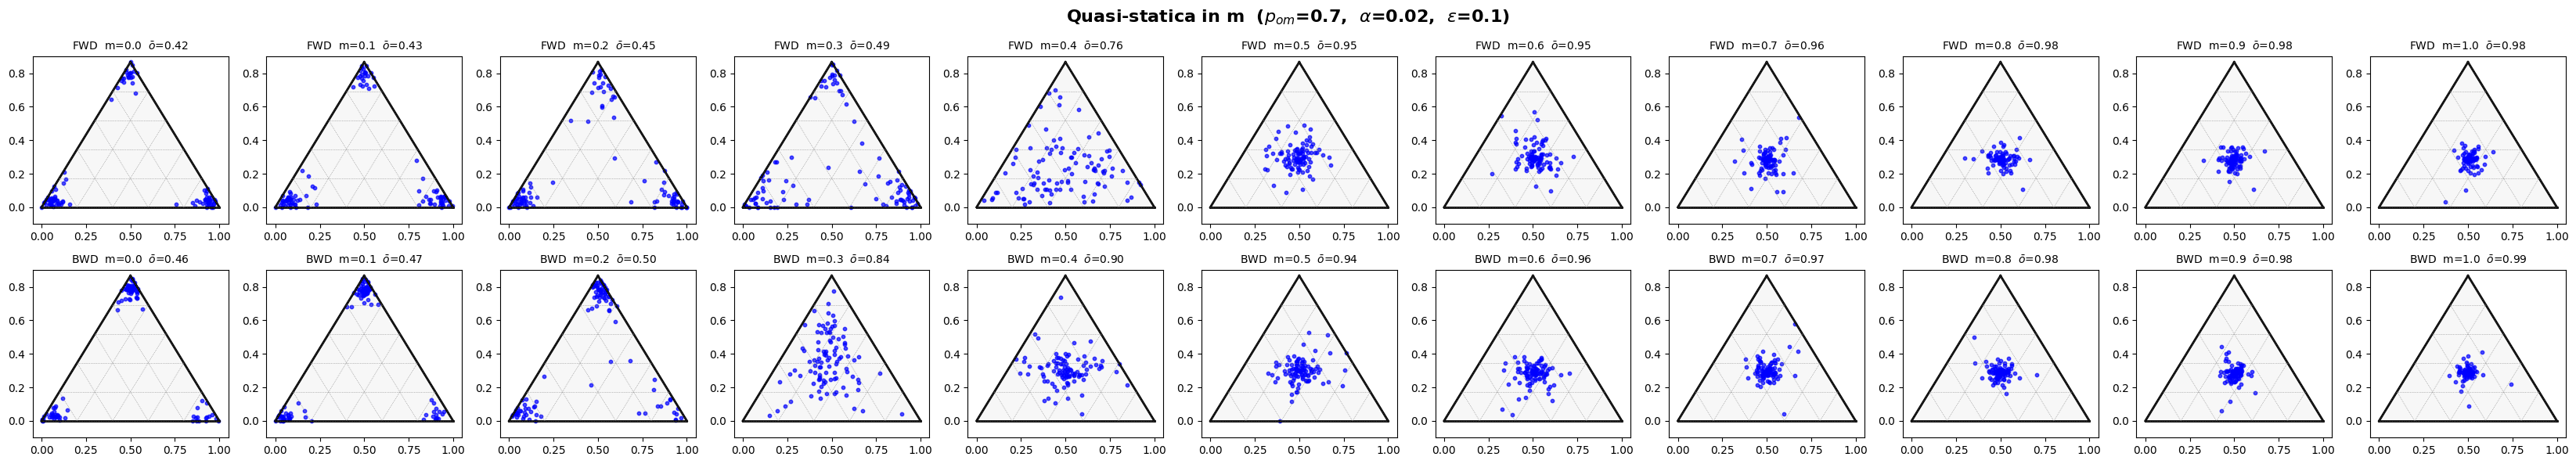

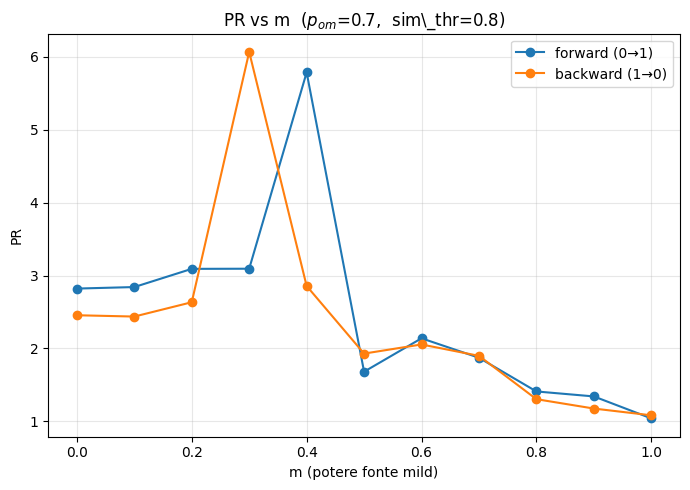

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[0.00000000e+00, 3.73015957e-02, 9.62698404e-01],
         [9.56352273e-01, 1.55229341e-03, 4.20954338e-02],
         [1.24059870e-02, 5.48119740e-02, 9.32782039e-01],
         [3.85714315e-02, 3.69986619e-02, 9.24429907e-01],
         [9.15000000e-01, 5.25000000e-02, 3.25000000e-02],
         [4.54621517e-02, 3.98457147e-02, 9.14692134e-01],
         [3.58720298e-02, 5.01421134e-02, 9.13985857e-01],
         [8.33709139e-01, 3.41118532e-02, 1.32179008e-01],
         [1.00000000e-02, 9.31170454e-01, 5.88295460e-02],
         [8.95295607e-01, 2.63353677e-02, 7.83690254e-02],
         [5.29447136e-02, 9.36466344e-01, 1.05889427e-02],
         [9.27130406e-01, 0.00000000e+00, 7.28695941e-02],
         [9.44102873e-01, 5.58971270e-02, 0.00000000e+00],
         [9.89566557e-02, 4.18712542e-02, 8.59172090e-01],
         [9.07237162e-01, 6.02611973e-02, 3.25016409e-02],
         [3.00000000e-02, 

In [54]:
entropy_threshold = 1.4
p_om = 0.7   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

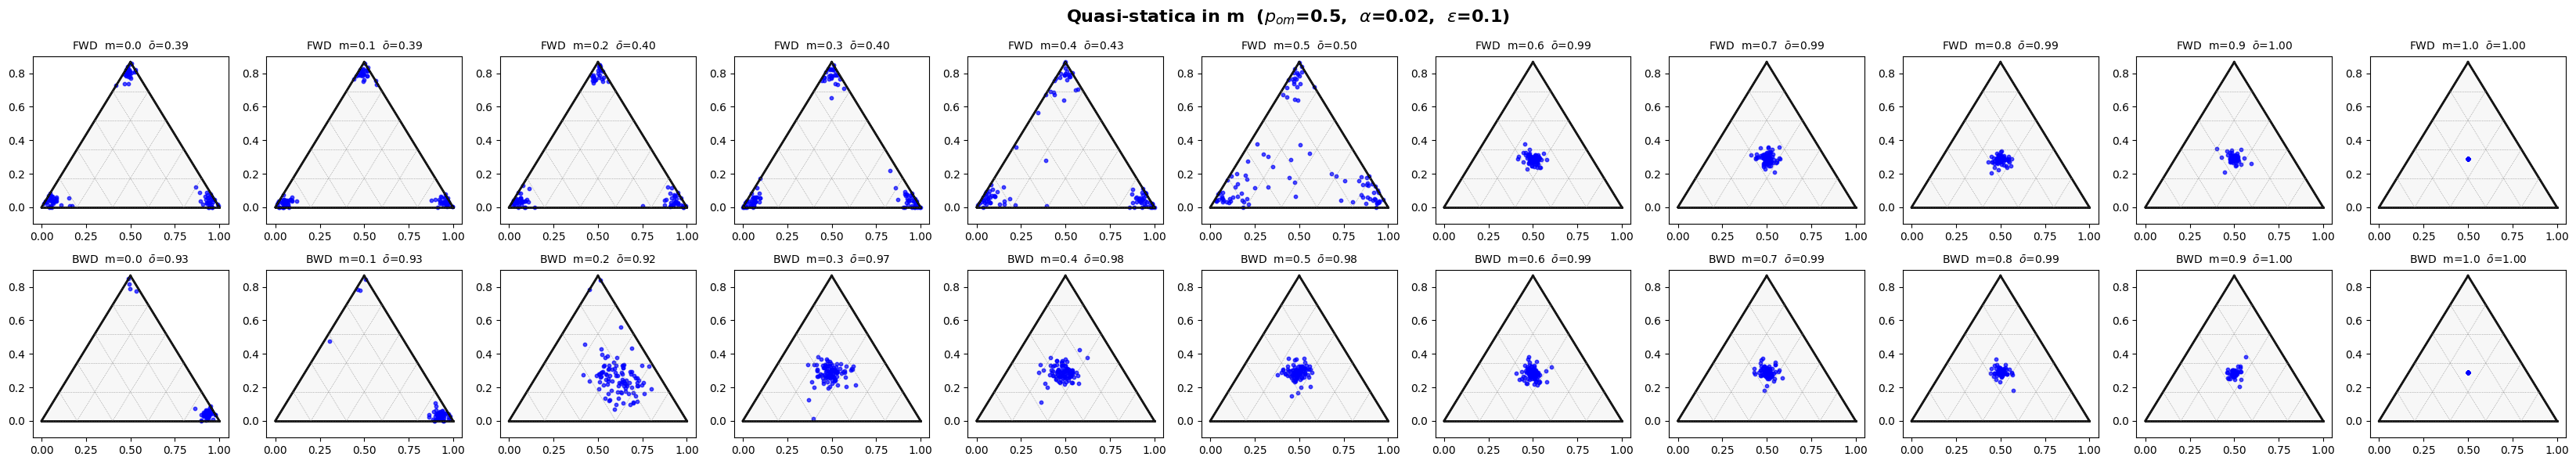

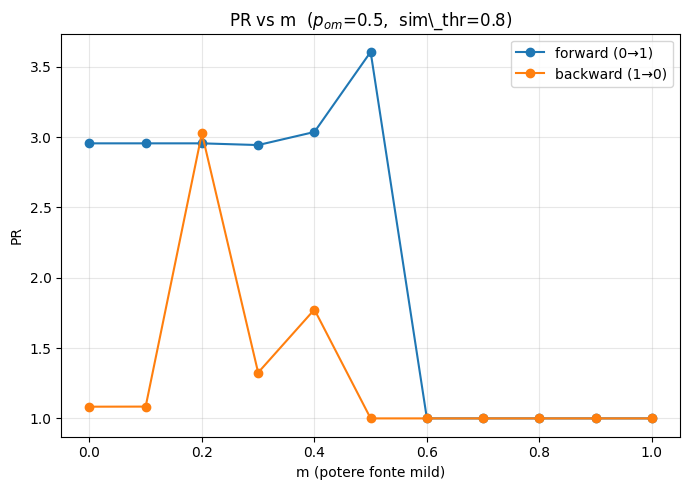

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[9.17657783e-01, 7.23422173e-02, 1.00000000e-02],
         [4.00000000e-02, 8.53558329e-01, 1.06441671e-01],
         [5.35463666e-02, 4.32986148e-02, 9.03155019e-01],
         [9.29482641e-01, 3.14827901e-02, 3.90345688e-02],
         [3.89632265e-02, 9.20107942e-01, 4.09288314e-02],
         [1.02467582e-01, 1.30385731e-02, 8.84493845e-01],
         [9.15225528e-01, 2.91683475e-02, 5.56061246e-02],
         [5.18407877e-02, 4.97916416e-02, 8.98367571e-01],
         [8.72905509e-01, 4.32044210e-02, 8.38900701e-02],
         [8.95921092e-01, 2.00000000e-02, 8.40789076e-02],
         [9.36433391e-01, 5.06069058e-02, 1.29597029e-02],
         [6.16386548e-02, 4.14752566e-02, 8.96886089e-01],
         [9.43850335e-01, 3.69236599e-02, 1.92260056e-02],
         [3.77484575e-02, 8.98167695e-01, 6.40838475e-02],
         [9.18305799e-01, 2.43223194e-02, 5.73718820e-02],
         [4.25276511e-02, 

In [51]:
entropy_threshold = 1.4
p_om = 0.5  

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

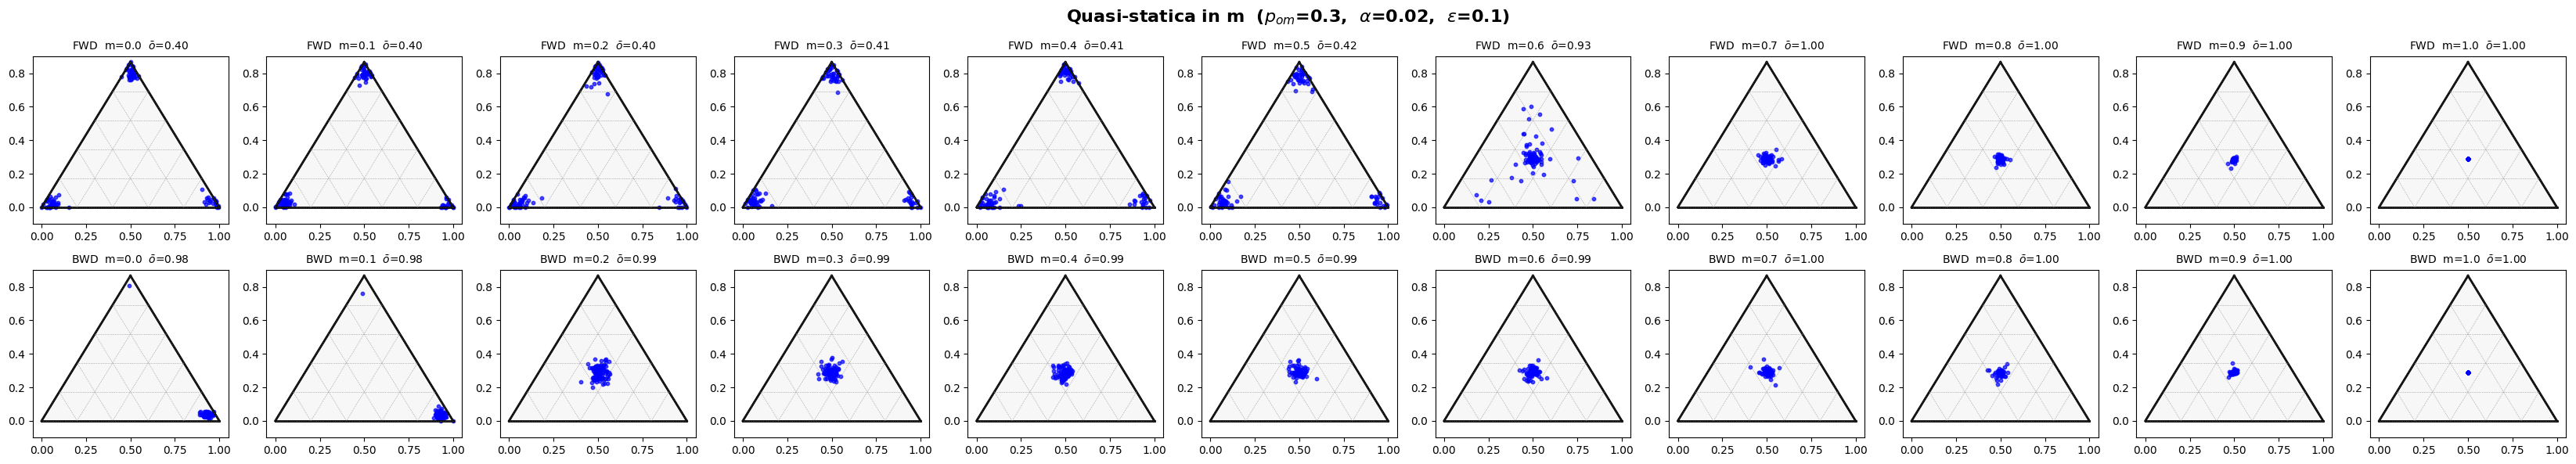

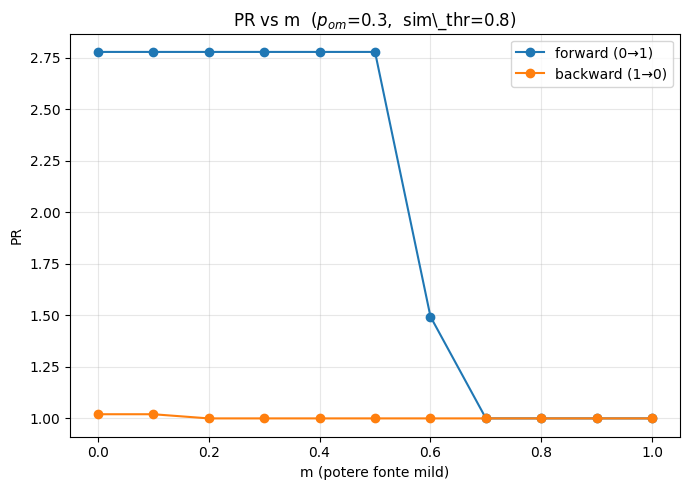

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[9.51040741e-01, 4.89592588e-02, 0.00000000e+00],
         [9.58868295e-01, 4.11317050e-02, 1.04083409e-17],
         [5.08102795e-02, 9.19189721e-01, 3.00000000e-02],
         [4.98292284e-03, 4.70625694e-02, 9.47954508e-01],
         [9.02725314e-01, 6.70553883e-02, 3.02192973e-02],
         [2.46368597e-02, 9.75363140e-01, 0.00000000e+00],
         [7.88975881e-02, 0.00000000e+00, 9.21102412e-01],
         [6.26609478e-03, 5.12541753e-02, 9.42479730e-01],
         [6.57537565e-02, 8.84246244e-01, 5.00000000e-02],
         [0.00000000e+00, 9.01282815e-01, 9.87171851e-02],
         [9.15069849e-01, 1.81816644e-02, 6.67484862e-02],
         [2.66056461e-02, 5.90934987e-02, 9.14300855e-01],
         [6.93011956e-02, 9.00594056e-01, 3.01047487e-02],
         [5.83529790e-02, 2.00000000e-02, 9.21647021e-01],
         [0.00000000e+00, 9.87489863e-01, 1.25101368e-02],
         [3.55271288e-02, 

In [52]:
entropy_threshold = 1.4
p_om = 0.3   

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)

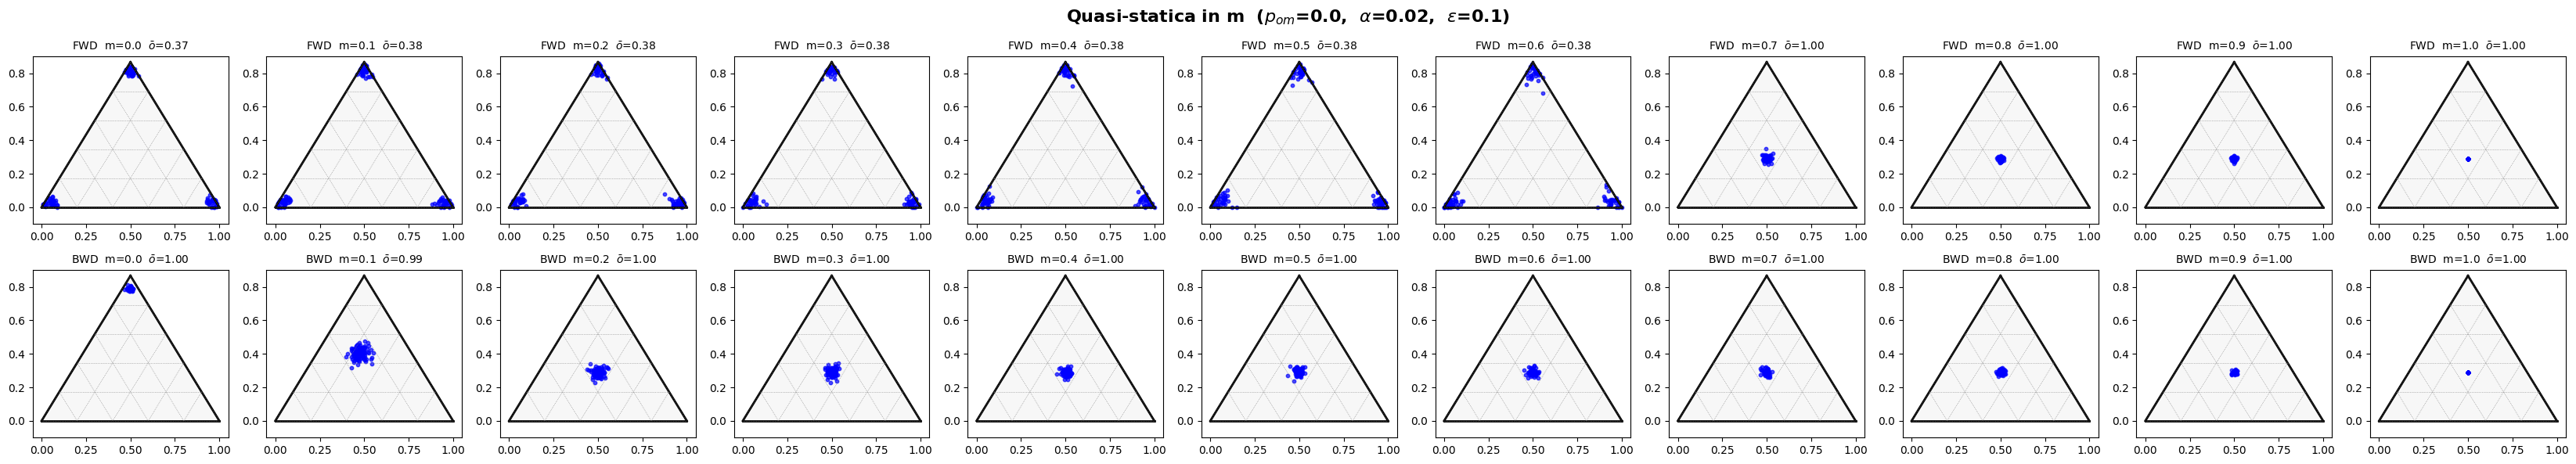

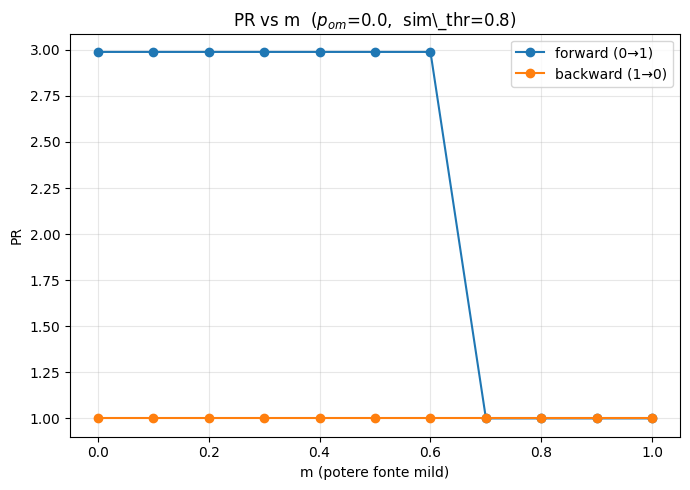

{'m_grid': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'states_fwd': [array([[1.26895251e-02, 4.14971416e-02, 9.45813333e-01],
         [9.01720135e-01, 6.28244916e-02, 3.54553738e-02],
         [9.48784933e-01, 4.25806254e-02, 8.63444144e-03],
         [0.00000000e+00, 9.50500382e-01, 4.94996184e-02],
         [9.28514886e-01, 2.23176314e-02, 4.91674823e-02],
         [7.47864338e-03, 3.08250743e-02, 9.61696282e-01],
         [2.43668157e-02, 4.44176441e-02, 9.31215540e-01],
         [4.00000000e-02, 9.34486395e-01, 2.55136050e-02],
         [8.82148364e-02, 0.00000000e+00, 9.11785164e-01],
         [2.80029672e-02, 6.76391103e-02, 9.04357923e-01],
         [9.39114486e-01, 4.39236761e-02, 1.69618380e-02],
         [1.04083409e-17, 9.30863662e-01, 6.91363379e-02],
         [9.70000000e-01, 0.00000000e+00, 3.00000000e-02],
         [9.53556184e-01, 4.43814346e-02, 2.06238103e-03],
         [2.82347750e-02, 4.49381910e-02, 9.26827034e-01],
         [5.45316249e-02, 

In [53]:
entropy_threshold = 1.4
p_om = 0.

run_quasistatic_m_sweep(
    PI, K, N, a, eps, alpha, time,
    entropy_threshold=entropy_threshold, p_om=p_om, similarity_threshold=0.8,
    m_grid=np.round(np.arange(0, 1.0+1e-9, 0.1), 2),
    make_plots=True,
    return_data=True
)